<a href="https://www.kaggle.com/code/vladosht/simple-stock-pricing-model?scriptVersionId=294543484" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

This notebook will present a model which attempts to make individual estimates whether a stock is overvalued or not. It is based on the fundamental financial data of 3000+ public companies, which report to the SEC and which are currently traded on US stock exchanges.

DISCLAIMER: The results of this model **must not** in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.

In [1]:
import json, torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model, preprocessing
from joblib import Parallel, delayed

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Torch threads:',torch.get_num_threads())
print(torch.ones(1, device=device),device)

Torch threads: 2
tensor([1.]) cpu


The model will be based on the following features and labels, taken from the SEC fundamentals dataset:

In [3]:
ml_features = ['Assets','Liabilities','NetCashOperating_ttm']
ml_label = 'price'
keys = ['snapshot','cik','date']
window_size = 12*3 #in number of snapshots

The model is called "simple", because it is rooted in this very basic assumption:  
Market_Capitalization = ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) \* hype + bias  
The business logic behind this formula is that the market capitalization of a company is dependent on its current static value (its equity) and its future cashflows. The following considerations apply:  
1. We assume the total assets of an individual company should never be taken at the nominal value that appears on the balance sheet, because they often contain a significant amount of "intangible" assets, for which it is notoriously difficult to arrive at a fair value. Therefore, we discount them with an asset_multiplier.
2. Liabilities, on the other hand, can be taken at nominal value, because it is a rare event for any kind of debt, accounts payable or the like, to be written off.
3. Then, the cash flows from operating activities can be modeled as a [perpetuity](https://en.wikipedia.org/wiki/Perpetuity). This is inspired by the idea for a [Steady State Cash Flow Model](https://www.google.com/search?q=%22Steady+State+Cash+Flow+Model%22) where we attempt to estimate the fair value of a company on the assumption that its business behaves the same way for the foreseeable future. In essence, we again discount the NetCashOperating_ttm with a cash_multiplier. We use the Trailing Twelve Months (ttm) value here, and not the quarterly value, because it smoothens any seasonalities and makes the model less erratic.
4. All of the above is multiplied by a "hype" parameter, which is the premium or penalty that the market gives to the total value of the company.
5. The bias further fine-tunes the company value to its market capitalization.  

However, it seems difficult to obtain freely available historic market capitalization data for individual companies. It turns out this is not really necessary. It is much easier to obtain historic prices and modelling the share price directly is even simpler.  
We do this by maximizing the **correlation coefficient** between our formula and the price. In short, we try to find such asset_multiplier and cash_multiplier parameters, for which the correlation between ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) and the price is equal to 1.

In [4]:
# We use this dataset to provide ticker descriptions later on.
with open('/kaggle/input/sec-edgar-cik-ticker-exchange/company_tickers_exchange.json',mode='rt') as f:
    jfile = json.load(f)
tickers = pd.DataFrame(columns=jfile['fields'],data=jfile['data'],dtype=str)
tickers = tickers[tickers['exchange']!='OTC'].dropna() #leave only tickers traded on an exchange
tickers['exchange'] = tickers['exchange'].str.upper().str.strip()
tickers['cik'] = tickers['cik'].str.zfill(10)
tickers['len'] = 4
tickers.loc[tickers[tickers['ticker'].str.contains('-')].index,'len'] += 1
tickers['ticker'] = tickers.apply(lambda row: str(row.ticker[:row.len]),axis='columns').str.rstrip().str.rstrip('-').str.upper()
tickers = tickers.sort_values(by=['cik','exchange','ticker']).drop_duplicates(subset=['cik'],keep='last').set_index('cik').drop(columns=['len'])
tickers

,name,ticker,exchange
cik,,,
0000001750,AAR CORP,AIR,NYSE
0000001800,ABBOTT LABORATORIES,ABT,NYSE
0000002098,ACME UNITED CORP,ACU,NYSE
0000002178,"ADAMS RESOURCES & ENERGY, INC.",AE,NYSE
0000002186,BK Technologies Corp,BKTI,NYSE
...,...,...,...
0001984060,Atlas Energy Solutions Inc.,AESI,NYSE
0001990550,"Ambrx Biopharma, Inc.",AMAM,NASDAQ
0001993004,"NorthWestern Energy Group, Inc.",NWE,NASDAQ


In [5]:
prices = pd.read_csv('/kaggle/input/monthly-us-stock-prices/prices.csv').rename(columns={'date':'snapshot'}).dropna()
prices['snapshot'] = pd.to_datetime(prices['snapshot']).dt.date
prices

,ticker,exchange,snapshot,price
0,A,NYSE - Delayed Quote,2010-02-01,20.05
1,A,NYSE - Delayed Quote,2010-03-01,22.50
2,A,NYSE - Delayed Quote,2010-04-01,24.60
3,A,NYSE - Delayed Quote,2010-05-01,25.94
4,A,NYSE - Delayed Quote,2010-06-01,23.15
...,...,...,...,...
604455,ZYME,NasdaqGS - Delayed Quote,2025-09-01,14.81
604456,ZYME,NasdaqGS - Delayed Quote,2025-10-01,17.08
604457,ZYME,NasdaqGS - Delayed Quote,2025-11-01,19.08
604458,ZYME,NasdaqGS - Delayed Quote,2025-12-01,26.71


In [6]:
raw_snapshots = pd.read_csv('/kaggle/input/fundamental-data-from-sec-xbrl-companyfacts-zip/snapshots.csv',dtype={'cik':str})
for i in ['snapshot','date']:
    raw_snapshots[i] = pd.to_datetime(raw_snapshots[i]).dt.date
raw_snapshots['timediff'] = pd.to_timedelta((raw_snapshots['snapshot'] - raw_snapshots['date'])).dt.days
raw_snapshots

,snapshot,cik,date,Assets,Revenue,COGS,GrossProfit,Equity,NetCashOperating,NetCashFinancing,...,Revenue_ttm,GrossProfit_ttm,NetCashOperating_ttm,NetCashFinancing_ttm,Earnings_ttm,ticker,exchange,PublicFloat,Employees,timediff
0,2012-01-01,0000001750,2011-11-30,1.821612,0.482000,0.403400,0.078600,0.863948,0.030412,-0.006559,...,1.920517,0.322328,0.083588,0.026485,0.073512,AIR,NYSE,0.934568,NaN,32
1,2012-01-01,0000001800,2011-09-30,59.628176,9.816682,3.973250,5.843432,24.603800,3.054430,-2.668122,...,38.441677,22.693948,9.885247,-4.831951,4.550604,ABT,NYSE,69.683329,NaN,93
2,2012-01-01,0000001961,2011-09-30,NaN,0.000000,0.000000,0.000000,NaN,-0.000067,0.000150,...,0.000188,0.000169,-0.000528,0.000456,-0.000968,NaN,NaN,NaN,NaN,93
3,2012-01-01,0000002034,2011-09-30,0.292355,0.101317,0.082798,0.018519,0.161372,0.005913,-0.001570,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93
4,2012-01-01,0000002098,2011-09-30,0.055344,0.019036,0.012396,0.006640,0.027561,0.003165,-0.000680,...,0.093494,0.033742,-0.003533,0.008428,0.004770,ACU,NYSE,NaN,NaN,93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090001,2026-01-24,0002082542,2025-09-30,0.000225,NaN,NaN,NaN,-0.000017,-0.000027,0.000064,...,NaN,NaN,NaN,NaN,NaN,BIXI,NASDAQ,NaN,NaN,116
1090002,2026-01-24,0002082844,2025-09-30,0.000197,NaN,NaN,NaN,-0.000034,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,SAC-U,NYSE,NaN,NaN,116
1090003,2026-01-24,0002084563,2025-09-30,0.000295,NaN,NaN,NaN,-0.000036,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,LFAC,NASDAQ,NaN,NaN,116
1090004,2026-01-24,0002088749,2025-09-30,0.000676,NaN,NaN,NaN,-0.000032,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,KBON,NASDAQ,NaN,NaN,116


Below we merge the fundamental data with the price data and do some dataset cleaning to maximize model performance. The datasets themselves are documented on their respective pages and you can refer to them for further insights about their structure.

In [7]:
snapshots = pd.merge(raw_snapshots,prices,on=['ticker','snapshot'],suffixes=('','_yahoo'),how='left')

# The key date (snapshot date) must always be later than the period-end date. We enforce this
# per cik using the timediff column - it must be positive for all records of a cik.
# We also ensure a window_size number of snapshots of historic data is available for each cik.
snapshots = snapshots[keys +['ticker'] + ml_features + [ml_label] + ['timediff']]
valid_ciks = snapshots.dropna().groupby(by='cik')['timediff'].aggregate(['min','count'])
valid_ciks = valid_ciks[(valid_ciks['min']>0)&(valid_ciks['count']>window_size)]
snapshots = snapshots.set_index(keys)
snapshots = snapshots.loc[(slice(None),valid_ciks.index.to_list()),:].sort_index().drop(columns='timediff')

# Ciks that have assets close to zero cause problems during training. We remove them
zero_asset_ciks = list(snapshots[snapshots['Assets'].fillna(0.0).abs()<1e-3].reset_index()['cik'].unique())
zero_asset_ciks = snapshots.loc[(slice(None),zero_asset_ciks),:].index
snapshots = snapshots.drop(index=zero_asset_ciks)

# There are several ciks, that have reported wrong data 1000 times larger than actual.
# They apparently never submitted a correction.
# This data disrupts the training and we remove the whole ciks.
asset_outliers = snapshots.groupby(by='cik')['Assets'].aggregate(['min','max'])
asset_outliers = asset_outliers['min']/asset_outliers['max']
asset_outliers = asset_outliers.sort_values().fillna(0.0)
asset_outliers = list(asset_outliers[asset_outliers<1e-3].reset_index()['cik'].unique())
asset_outliers = snapshots.loc[(slice(None),asset_outliers),:].index
snapshots = snapshots.drop(index=asset_outliers)

# There are 100+ ciks that report too infrequently, i.e. less than 4 times a year.
# These are mostly foreign (non-US) entities that nevertheless trade on US exchanges.
# Whatever the cause, ciks that report less often than 4 times a year distort the model and we
# remove them. We determine the reporting frequency by the unique Asset values reported per year.
too_few_reports = snapshots[['Assets']].dropna()
too_few_reports['year'] = pd.to_datetime(too_few_reports.index.get_level_values(0)).year
too_few_reports = too_few_reports.groupby(by=['cik','year'])['Assets'].nunique().groupby('cik').max()
too_few_reports = snapshots.loc[(slice(None),too_few_reports[too_few_reports<4].index),:].index
snapshots = snapshots.drop(index=too_few_reports)

snapshots

ticker     Assets  Liabilities  \
snapshot   cik        date                                        
2012-01-01 0000001750 2011-11-30    AIR   1.821612     0.957664   
           0000001800 2011-09-30    ABT  59.628176    35.024376   
           0000002098 2011-09-30    ACU   0.055344     0.027783   
           0000002488 2011-10-01    AMD   5.236000     3.492000   
           0000002969 2011-09-30    APD  14.290700     8.494900   
...                                 ...        ...          ...   
2026-01-24 0001905956 2025-09-30    TGL   0.016595     0.004622   
           0001906324 2025-09-28   QDEL   5.675100     3.638700   
           0001907982 2025-09-30   QBTS   0.865820     0.195266   
           0001914605 2025-09-30   ECBK   1.552653     1.383344   
           0001915657 2025-09-30   DINO  17.264000     7.834000   

                                  NetCashOperating_ttm  price  
snapshot   cik        date                                     
2012-01-01 0000001750 2011-11-30              0.083588  19.17  
           0000001800 2011-09-30              9.885247  26.98  
           0000002098 2011-09-30             -0.003533   9.50  
           0000002488 2011-10-01             -0.018000   5.40  
           0000002969 2011-09-30              1.753200  78.81  
...                                                ...    ...  
2026-01-24 0001905956 2025-09-30             -0.010266    NaN  
           0001906324 2025-09-28              0.037000    NaN  
           0001907982 2025-09-30             -0.051593    NaN  
           0001914605 2025-09-30              0.009768    NaN  
           0001915657 2025-09-30              1.167000    NaN  

[437897 rows x 5 columns]

Machine learning algorithms in general cannot handle NaN values. The data we feed into our algorithm later must not only be free of NaNs, but it must also be symmetrical, i.e., for each cik there must be the same number of snapshots in the dataset. This is of course not the case in the raw data, so we create rows where they do not exist for a particular cik/snapshot combination. Then we replace all NaNs with zero, but we do retain information in a new column (is_created) whether a row was artificially created or not.

In [8]:
ml_input_df = snapshots.dropna().copy()
ml_input_df['is_created'] = False
unique_snapshot_dates = ml_input_df.index.get_level_values(0).unique().sort_values().to_series()
unique_ciks = ml_input_df.index.get_level_values(1).unique().sort_values().to_series()
print("There are {} unique snapshots and {} unique ciks for a total of {} records.".format(
    len(unique_snapshot_dates),len(unique_ciks),len(unique_snapshot_dates)*len(unique_ciks)))

ml_input_df = pd.merge(pd.merge(unique_snapshot_dates, unique_ciks, how='cross'),
                       ml_input_df[ml_features+[ml_label,'is_created']].reset_index(drop=False),how='left')
ml_input_df = ml_input_df.drop(columns=['date']).set_index(['cik','snapshot']).sort_index()
ml_input_df['is_created'] = ml_input_df['is_created'].isna()
ml_input_df = ml_input_df.fillna(0.0)
ml_input_df

There are 169 unique snapshots and 3213 unique ciks for a total of 542997 records.


Assets  Liabilities  NetCashOperating_ttm  price  \
cik        snapshot                                                          
0000001750 2012-01-01   1.821612     0.957664              0.083588  19.17   
           2012-02-01   1.821612     0.957664              0.083588  21.19   
           2012-03-01   1.821612     0.957664              0.083588  22.05   
           2012-04-01   2.220293     1.330213              0.066898  18.25   
           2012-05-01   2.220293     1.330213              0.066898  15.45   
...                          ...          ...                   ...    ...   
0001915657 2025-09-01  16.843000     7.561000              1.067000  50.88   
           2025-10-01  16.843000     7.561000              1.067000  52.34   
           2025-11-01  17.264000     7.834000              1.167000  51.60   
           2025-12-01  17.264000     7.834000              1.167000  52.91   
           2026-01-01  17.264000     7.834000              1.167000  46.08   

                       is_created  
cik        snapshot                
0000001750 2012-01-01       False  
           2012-02-01       False  
           2012-03-01       False  
           2012-04-01       False  
           2012-05-01       False  
...                           ...  
0001915657 2025-09-01       False  
           2025-10-01       False  
           2025-11-01       False  
           2025-12-01       False  
           2026-01-01       False  

[542997 rows x 5 columns]

The cell below is the heart of our machine learning model. The following is critical for the loss function we want to use - the correlation coefficient between our model formula and the price. Unfortunately the built-in PyTorch function can handle only pairs of 1d tensors, so with the help of Google's Gemini AI we re-created it to handle our multi-dimensional data.

Gemini states that: "Cosine similarity is equivalent to Pearson correlation only if the input vectors are first centered (mean is zero)". There is a quite nice CosineSimilarity class in PyTorch, so we extend it to fit our needs for a custom loss function.

From our previous [whole-market model](https://www.kaggle.com/code/vladosht/s-p-500-fundamental-data-model) we know that the market as a whole does not adjust the total assets away from their nominal value. We put this knowledge into the loss function by minimizing the ratio between total adjusted assets for all ciks and total unadjusted assets for all ciks (component market_assets_loss)

In [9]:
class MyPearsonLoss(torch.nn.CosineSimilarity):
    def forward(self, x1, x2, assets, asmul):
        
        pearson = super().forward(x1 - x1.mean(dim=1, keepdim=True),
                                  x2 - x2.mean(dim=1, keepdim=True))

        # If pearson = -1 -> corr = 2 (worst case)
        # If pearson =  0 -> corr = 1 (bad case)
        # If pearson =  1 -> corr = 0 (best case)
        corr = 1 - pearson

        self.correlation_loss = corr.sum() + corr.std()
        
        # The market as a whole does not adjust the total assets away from their nominal value:
        adjusted_assets = assets * 10**asmul.unsqueeze(1)
        self.market_assets_loss = (adjusted_assets.sum(dim=0) / assets.sum(dim=0) - 1).abs().sum()
        
        # We need some kind of regularization for the asset_multiplier,
        # otherwise the values become erratic and uncomparable across ciks
        self.asmul_loss = 10 * asmul.mean().abs() + asmul.std()
        
        # The total loss is just a weighted sum of the individual loss components
        total_loss = self.correlation_loss + self.market_assets_loss + 10 * self.asmul_loss
        
        return total_loss
        
    def get_param_state(self):
        """ Return a dictionary with the individual loss components """
        return { i:getattr(self,i).item() for i in dir(self) if '_loss' in i }

What follows is the actual model implementation. We need to clarify several things here:
1. We compute the asset_multiplier on per-cik basis, but the cash_multiplier is only computed on per-snapshot basis. The reasoning behind this is that it is much more logical to assume that the discount rate for the NetCashOperating_ttm is the same for all ciks on a given date, something like a common interest rate for all companies that depends not on individual companies, but on general interest and inflation levels and return-on-investment expectations of investors. This also makes the model more generalized.
2. The asset_multiplier is enforced to be always positive by exponentiating the actual parameter we are trying to find. I.e., final asset_multiplier = 10 \*\* (internal parameter)
3. The model results are returned by the get_df method, which simply takes the input dataframe and extends it with two additional columns for the asset_multiplier and cash_multiplier. It also returns a column for the computed model value. Remember, this model value only correlates well with the price, it is not equal to the price.

In [10]:
class SimplePricingModel(torch.nn.Module):
    def __init__(self, df, print_shape=True):
        super().__init__()
        self.print_shape = print_shape
        self.df          = df
        self.columns     = df.columns.to_list()
        self.columns     = { i:self.columns.index(i) for i in self.columns }
        self.ciks        = df.index.get_level_values(0).unique()
        self.len_ciks    = len(self.ciks)
        self.len_snapshots = len(df.index.get_level_values(1).unique())
        self.asmul       = torch.nn.Parameter(0.1 + torch.rand(self.len_ciks))
        self.cashmul     = torch.nn.Parameter(0.1 + torch.rand(self.len_snapshots))
        self.ml_input    = torch.nn.Buffer(torch.tensor(df[ml_features].to_numpy()).reshape(self.len_ciks,self.len_snapshots,-1))
        self.labels      = torch.nn.Buffer(torch.tensor(df[ml_label].to_numpy()).reshape(self.len_ciks,self.len_snapshots))
        if self.print_shape:
            print('Input shape:',self.ml_input.shape)
            print('Labels shape:',self.labels.shape)
            print('Asset multiplier shape:',self.asmul.shape)
            print('Cash multiplier shape:',self.cashmul.shape)
    
    def get_param_state(self):
        return { "median cashmul" : self.cashmul.median().item(), "median asmul" : (10 ** self.asmul).median().item() }

    def forward(self):
        adjusted_assets   = self.ml_input[:,:,self.columns['Assets']] * 10**self.asmul.unsqueeze(1)
        liabilities       = self.ml_input[:,:,self.columns['Liabilities']]
        adjusted_cashflow = self.ml_input[:,:,self.columns['NetCashOperating_ttm']] * self.cashmul.unsqueeze(0)
        fwd = adjusted_assets - liabilities + adjusted_cashflow
        if self.print_shape:
            print('Adjusted assets shape:', adjusted_assets.shape)     
            print('Adjusted cashflow shape:', adjusted_cashflow.shape)     
            print('Forward shape:', fwd.shape)
            self.print_shape = False
        return fwd

    def get_df(self):
        asmul = pd.Series(index=self.ciks, data = self.asmul.reshape(-1).cpu().detach().numpy()).rename('asmul')
        asmul = 10**asmul
        cashmul = self.cashmul.cpu().detach().numpy()
        cashmul = pd.Series(index=self.df.index.get_level_values(1).unique().sort_values(), data=cashmul).rename('cashmul')

        ret_df = pd.merge(self.df,asmul,left_index=True,right_index=True)
        ret_df = pd.merge(ret_df,cashmul,left_index=True,right_index=True)
        ret_df['model'] = self.forward().reshape(-1).cpu().detach().numpy()
        return ret_df

pricing_model = SimplePricingModel(ml_input_df).to(device)
pricing_model.ml_input.device

Input shape: torch.Size([3213, 169, 3])
Labels shape: torch.Size([3213, 169])
Asset multiplier shape: torch.Size([3213])
Cash multiplier shape: torch.Size([169])


device(type='cpu')

Adjusted assets shape: torch.Size([3213, 169])
Adjusted cashflow shape: torch.Size([3213, 169])
Forward shape: torch.Size([3213, 169])
Epoch [1000/6000], Loss=939.27947784
Epoch [2000/6000], Loss=938.58767125
Epoch [3000/6000], Loss=938.32783814
Epoch [4000/6000], Loss=938.17678709
Epoch [5000/6000], Loss=938.18311487
Epoch [6000/6000], Loss=937.91888922


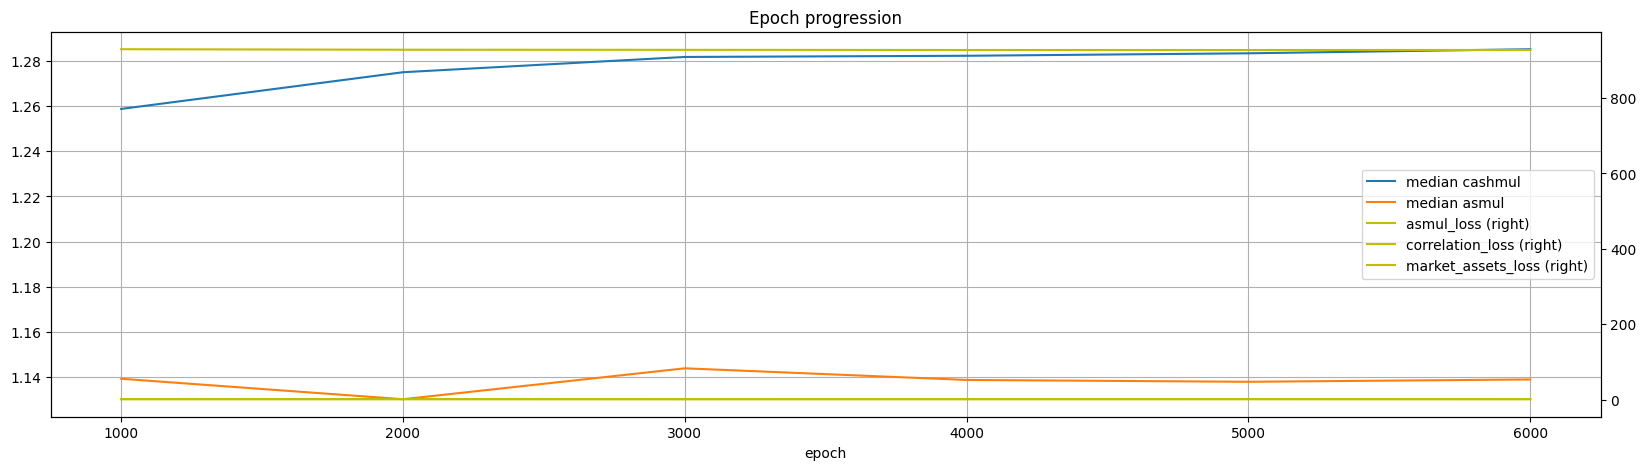

,median cashmul,median asmul,asmul_loss,correlation_loss,market_assets_loss
epoch,,,,,
1000,1.258673,1.139384,0.828978,929.860536,1.129167
2000,1.274903,1.130335,0.887020,928.525916,1.191550
3000,1.281654,1.143999,0.910838,928.247671,0.971784
4000,1.282177,1.138855,0.929362,927.811341,1.071822
5000,1.283267,1.138041,0.923051,927.743839,1.208763
6000,1.285073,1.139072,0.905475,927.887578,0.976560


In [11]:
def model_train(model, num_epochs = 6000, epoch_batch = 1000):
    optimizer = torch.optim.Adagrad(params = model.parameters(), lr = 0.2)
    loss_function = MyPearsonLoss()

    output_graphic = []

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        y_pred = model.forward()
        loss = loss_function(y_pred, model.labels,
                             model.ml_input[:,:,model.columns['Assets']],
                             model.asmul)
        loss.backward()
        optimizer.step()
        if (epoch+1) % epoch_batch == 0:
            param_state = { 'epoch':epoch+1, **model.get_param_state(), **loss_function.get_param_state() }
            output_graphic.append(param_state)
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss={loss.item():.8f}")

    output_graphic = pd.DataFrame(output_graphic).set_index('epoch')
    loss_cols = [ a_col for a_col in output_graphic.columns if 'loss' in str(a_col) ]
    output_graphic.drop(columns=loss_cols).plot(grid=True,figsize=(20,5),legend=True,title='Epoch progression')
    for a_loss_col in loss_cols:
        output_graphic[a_loss_col].plot(secondary_y=True,legend=True,grid=False,c='y')
    plt.show()
    return output_graphic

model_train(pricing_model)

In [12]:
model_output = pricing_model.get_df()
model_output = model_output[~model_output['is_created']].drop(columns=['is_created'])
model_output

Assets  Liabilities  NetCashOperating_ttm  price  \
cik        snapshot                                                          
0000001750 2012-01-01   1.821612     0.957664              0.083588  19.17   
           2012-02-01   1.821612     0.957664              0.083588  21.19   
           2012-03-01   1.821612     0.957664              0.083588  22.05   
           2012-04-01   2.220293     1.330213              0.066898  18.25   
           2012-05-01   2.220293     1.330213              0.066898  15.45   
...                          ...          ...                   ...    ...   
0001915657 2025-09-01  16.843000     7.561000              1.067000  50.88   
           2025-10-01  16.843000     7.561000              1.067000  52.34   
           2025-11-01  17.264000     7.834000              1.167000  51.60   
           2025-12-01  17.264000     7.834000              1.167000  52.91   
           2026-01-01  17.264000     7.834000              1.167000  46.08   

                          asmul   cashmul     model  
cik        snapshot                                  
0000001750 2012-01-01  1.001549 -1.183296  0.767861  
           2012-02-01  1.001549 -1.051388  0.778887  
           2012-03-01  1.001549 -0.979141  0.784926  
           2012-04-01  1.001549 -0.904925  0.832983  
           2012-05-01  1.001549 -0.930003  0.831305  
...                         ...       ...       ...  
0001915657 2025-09-01  0.801487  1.640453  7.688806  
           2025-10-01  0.801487  1.628610  7.676169  
           2025-11-01  0.801487  1.507706  7.762361  
           2025-12-01  0.801487  1.548493  7.809960  
           2026-01-01  0.801487  1.554836  7.817361  

[422244 rows x 7 columns]

In [13]:
# We take the computed multipliers and put them into the original dataframe "snapshots"
mul_columns = ['asmul','cashmul']
result = pd.merge(snapshots,
                  model_output.groupby(by=['snapshot','cik'])[mul_columns].mean(),
                  left_index=True, right_index=True, how='left')
result['model'] = result['asmul']*result['Assets'] - result['Liabilities'] + result['cashmul']*result['NetCashOperating_ttm']

# The model values and the prices correlate by design, so the simplest linear regression will yield
# a conversion between them.
def line_fit(a_group):
    (ticker, cik), df = a_group
    train_data = df[['model','price']].dropna()
    regressor = linear_model.LinearRegression().fit(X=train_data[['model']],y=train_data['price'])
    df['slope'] = regressor.coef_[0]
    df['intercept'] = regressor.intercept_
    return df

with Parallel(n_jobs=-1) as p:
    result = pd.concat(p(delayed(line_fit)(i) for i in result.groupby(by=['ticker','cik'])))
    
result = result.reset_index().set_index(['snapshot','cik','date']).sort_index()

# Sample data: Amazon
result[result['ticker']=='AMZN'].tail(20)

,,,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,slope,intercept
snapshot,cik,date,,,,,,,,,,
2024-07-01,0001018724,2024-03-31,AMZN,530.969,314.308,159.120667,193.25,0.5508,1.307503,186.200701,0.585514,50.796998
2024-08-01,0001018724,2024-03-31,AMZN,530.969,314.308,159.120667,186.98,0.5508,1.574502,228.685742,0.585514,50.796998
2024-09-01,0001018724,2024-06-30,AMZN,554.818,318.371,177.090000,178.50,0.5508,1.604134,271.299017,0.585514,50.796998
2024-10-01,0001018724,2024-06-30,AMZN,554.818,318.371,177.090000,186.33,0.5508,1.640324,277.707953,0.585514,50.796998
2024-11-01,0001018724,2024-06-30,AMZN,554.818,318.371,177.090000,186.40,0.5508,1.564285,264.242172,0.585514,50.796998
2024-12-01,0001018724,2024-09-30,AMZN,584.626,325.475,193.943333,207.89,0.5508,1.843191,354.011824,0.585514,50.796998
2025-01-01,0001018724,2024-09-30,AMZN,584.626,325.475,193.943333,219.39,0.5508,1.565210,300.099231,0.585514,50.796998
2025-02-01,0001018724,2024-09-30,AMZN,584.626,325.475,193.943333,237.68,0.5508,1.648296,316.213187,0.585514,50.796998
2025-03-01,0001018724,2024-12-31,AMZN,624.894,338.924,197.114333,212.28,0.5508,1.564403,313.634153,0.585514,50.796998


Let's examine the achieved correlations using a histogram:

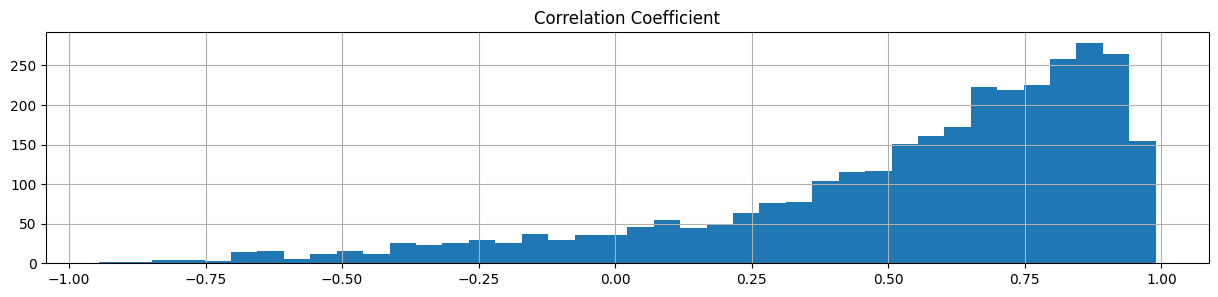

In [14]:
model_corr = result.dropna().groupby(by='cik')[[ml_label,'model']].corr().reset_index()
model_corr = model_corr[model_corr[model_corr.columns[1]]==ml_label][['cik','model']]
model_corr = model_corr.rename(columns={'model':'Correlation Coefficient'}).set_index('cik')
model_corr.hist(figsize=(15,3),bins=40)
plt.show()

It is interesting to see the development of the two multipliers over time. The cash multiplier is the same for all ciks on a given snapshot date and can probably serve as some form of valuation metric for the whole market.

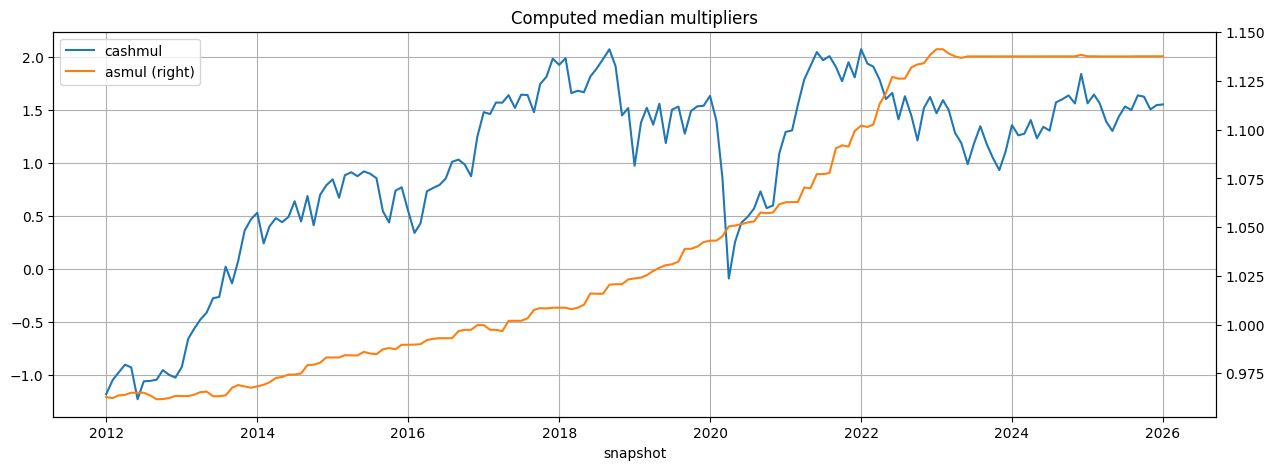

Median asset_multiplier per cik: 1.139072060585022
Median asset_multiplier per snapshot: 1.0237160921096802


In [15]:
mul_graph = result.groupby(by='snapshot')[mul_columns].median()
mul_graph['cashmul'].plot(title='Computed median multipliers',figsize=(15,5),grid=True,legend=True)
mul_graph['asmul'].plot(secondary_y=True,legend=True,grid=False)
plt.show()
print("Median asset_multiplier per cik:",result['asmul'].groupby(by=['cik']).median().median())
print("Median asset_multiplier per snapshot:",result['asmul'].groupby(by=['snapshot']).median().median())

We can now output the results for later use in other models/notebooks/datasets

In [16]:
result.to_csv('/kaggle/working/pricing_model.csv.gz')

Finally, we apply the model to individual companies. I have tried to make the selection of sample tickers as varied as possible in terms of company kinds and sizes. Using the computed model values we can arrive at a fair price for each snapshot, that can be used to make some estimates if and how much the stock price corresponds to the underlying financials.

In other words, we may be able to determine if a stock is relatively over-or-undervalued, compared to its historic fundamentals.

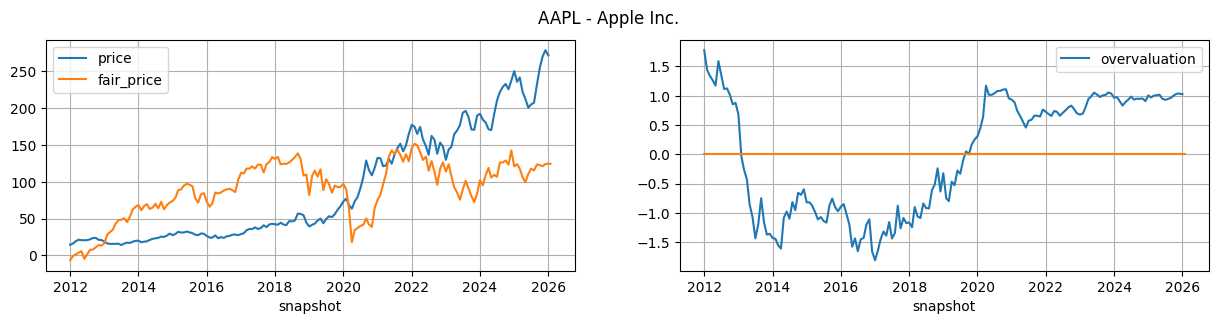

AAPL fair_price = 0.654518 * (0.940179 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -22.984725


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000320193,2025-06-28,AAPL,331.495,265.665,108.565,0.940179,1.628610,0.654518,-22.984725,222.809832,122.848298
2025-11-01,0000320193,2025-09-27,AAPL,359.241,285.508,111.482,0.940179,1.507706,0.654518,-22.984725,220.325089,121.221990
2025-12-01,0000320193,2025-09-27,AAPL,359.241,285.508,111.482,0.940179,1.548493,0.654518,-22.984725,224.872117,124.198100
2026-01-01,0000320193,2025-09-27,AAPL,359.241,285.508,111.482,0.940179,1.554836,0.654518,-22.984725,225.579208,124.660904
2026-01-24,0000320193,2025-09-27,AAPL,359.241,285.508,111.482,0.940179,1.554836,0.654518,-22.984725,225.579208,124.660904


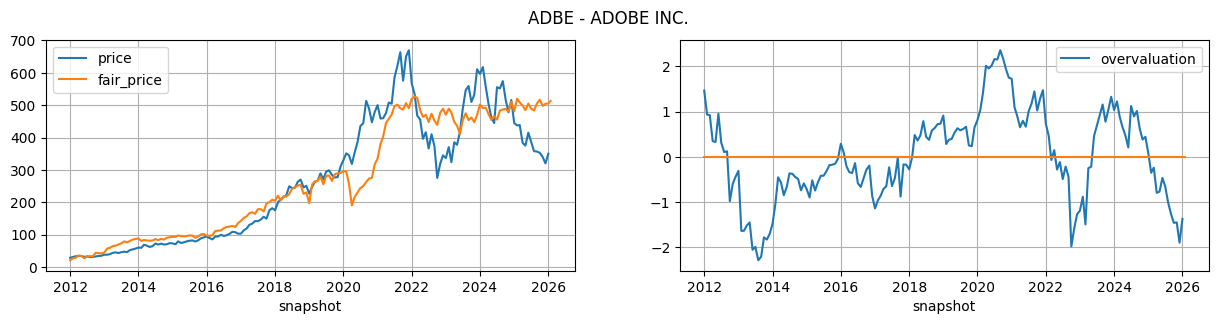

ADBE fair_price = 16.070522 * (1.350733 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -90.708926


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000796343,2025-08-29,ADBE,28.754,16.984,9.792,1.350733,1.628610,16.070522,-90.708926,37.802315,516.793992
2025-11-01,0000796343,2025-08-29,ADBE,28.754,16.984,9.792,1.350733,1.507706,16.070522,-90.708926,36.618423,497.768235
2025-12-01,0000796343,2025-08-29,ADBE,28.754,16.984,9.792,1.350733,1.548493,16.070522,-90.708926,37.017810,504.186597
2026-01-01,0000796343,2025-08-29,ADBE,28.754,16.984,9.792,1.350733,1.554836,16.070522,-90.708926,37.079917,505.184693
2026-01-24,0000796343,2025-11-28,ADBE,29.496,17.873,10.031,1.350733,1.554836,16.070522,-90.708926,37.564767,512.976475


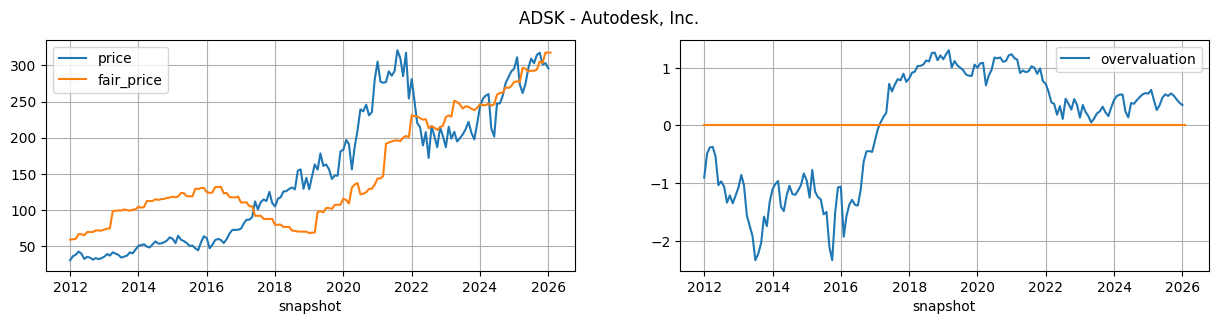

ADSK fair_price = 8.318165 * (4.180336 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -30.272293


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000769397,2025-07-31,ADSK,10.856,8.141,1.925,4.180336,1.628610,8.318165,-30.272293,40.375807,305.580320
2025-11-01,0000769397,2025-07-31,ADSK,10.856,8.141,1.925,4.180336,1.507706,8.318165,-30.272293,40.143067,303.644350
2025-12-01,0000769397,2025-10-31,ADSK,11.198,8.305,2.155,4.180336,1.548493,8.318165,-30.272293,41.843411,317.788088
2026-01-01,0000769397,2025-10-31,ADSK,11.198,8.305,2.155,4.180336,1.554836,8.318165,-30.272293,41.857079,317.901784
2026-01-24,0000769397,2025-10-31,ADSK,11.198,8.305,2.155,4.180336,1.554836,8.318165,-30.272293,41.857079,317.901784


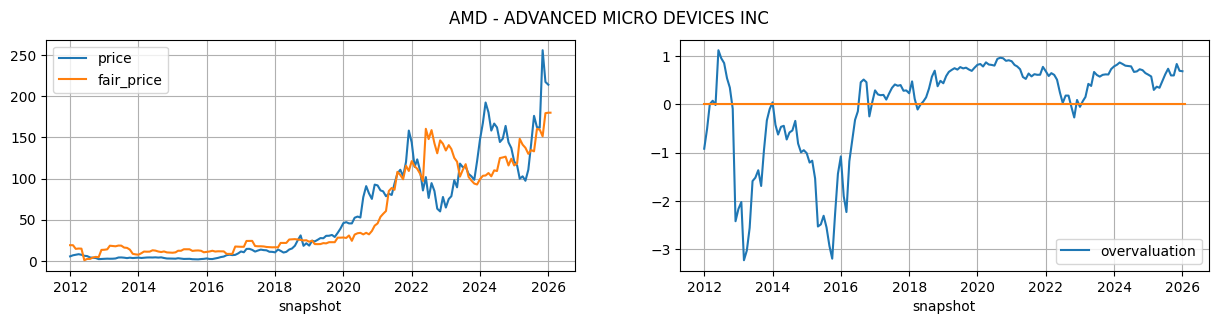

AMD fair_price = 13.821921 * (0.199913 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +52.499476


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000002488,2025-06-28,AMD,74.820,15.155,4.877,0.199913,1.628610,13.821921,52.499476,7.745210,159.553151
2025-11-01,0000002488,2025-06-28,AMD,74.820,15.155,4.877,0.199913,1.507706,13.821921,52.499476,7.155561,151.403074
2025-12-01,0000002488,2025-09-27,AMD,76.891,16.101,6.408,0.199913,1.548493,13.821921,52.499476,9.193242,179.567744
2026-01-01,0000002488,2025-09-27,AMD,76.891,16.101,6.408,0.199913,1.554836,13.821921,52.499476,9.233886,180.129518
2026-01-24,0000002488,2025-09-27,AMD,76.891,16.101,6.408,0.199913,1.554836,13.821921,52.499476,9.233886,180.129518


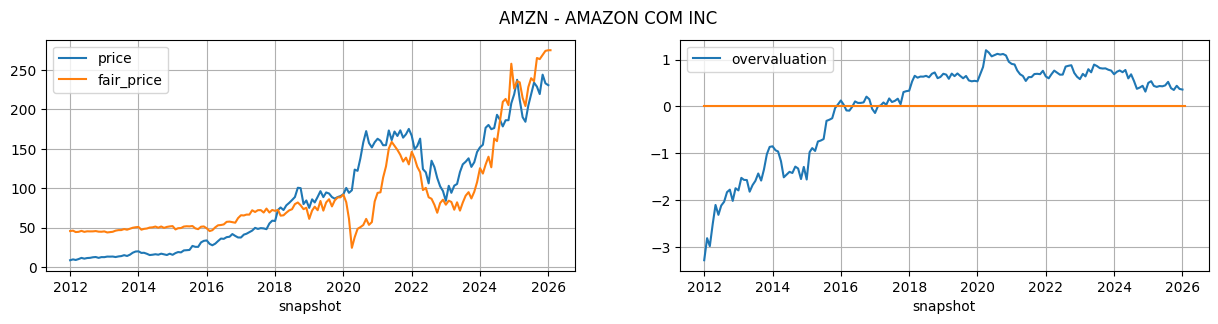

AMZN fair_price = 0.585514 * (0.550800 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +50.796998


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001018724,2025-06-30,AMZN,682.170,348.395,206.735833,0.5508,1.628610,0.585514,50.796998,364.036529,263.945410
2025-11-01,0001018724,2025-09-30,AMZN,727.921,358.290,219.100167,0.5508,1.507706,0.585514,50.796998,372.987795,269.186499
2025-12-01,0001018724,2025-09-30,AMZN,727.921,358.290,219.100167,0.5508,1.548493,0.585514,50.796998,381.924255,274.418920
2026-01-01,0001018724,2025-09-30,AMZN,727.921,358.290,219.100167,0.5508,1.554836,0.585514,50.796998,383.313931,275.232594
2026-01-24,0001018724,2025-09-30,AMZN,727.921,358.290,219.100167,0.5508,1.554836,0.585514,50.796998,383.313931,275.232594


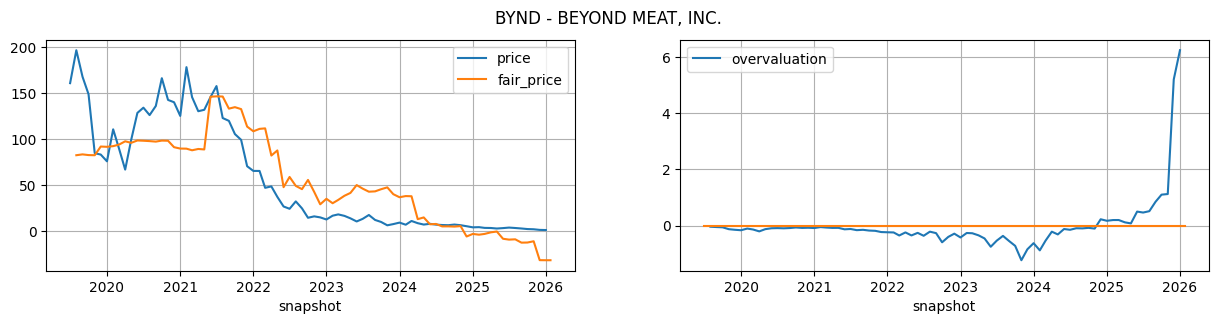

BYND fair_price = 102.089680 * (1.692736 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +25.780548


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001655210,2025-06-28,BYND,0.691741,1.368764,-0.110354,1.692735,1.628610,102.08968,25.780548,-0.377553,-12.763749
2025-11-01,0001655210,2025-06-28,BYND,0.691741,1.368764,-0.110354,1.692735,1.507706,102.08968,25.780548,-0.364211,-11.401644
2025-12-01,0001655210,2025-09-27,BYND,0.599669,1.383734,-0.127090,1.692735,1.548493,102.08968,25.780548,-0.565451,-31.946183
2026-01-01,0001655210,2025-09-27,BYND,0.599669,1.383734,-0.127090,1.692735,1.554836,102.08968,25.780548,-0.566257,-32.028476
2026-01-24,0001655210,2025-09-27,BYND,0.599669,1.383734,-0.127090,1.692735,1.554836,102.08968,25.780548,-0.566257,-32.028476


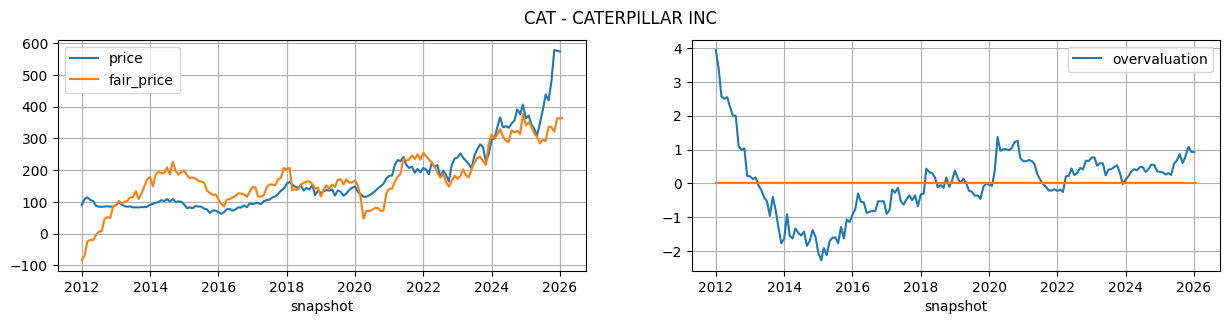

CAT fair_price = 10.436521 * (1.374589 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -406.019771


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000018230,2025-06-30,CAT,90.325,71.662,11.373,1.374589,1.628610,10.436521,-406.019771,71.019899,335.180869
2025-11-01,0000018230,2025-06-30,CAT,90.325,71.662,11.373,1.374589,1.507706,10.436521,-406.019771,69.644858,320.830227
2025-12-01,0000018230,2025-09-30,CAT,93.722,73.063,11.541,1.374589,1.548493,10.436521,-406.019771,73.637354,362.497994
2026-01-01,0000018230,2025-09-30,CAT,93.722,73.063,11.541,1.374589,1.554836,10.436521,-406.019771,73.710555,363.261953
2026-01-24,0000018230,2025-09-30,CAT,93.722,73.063,11.541,1.374589,1.554836,10.436521,-406.019771,73.710555,363.261953


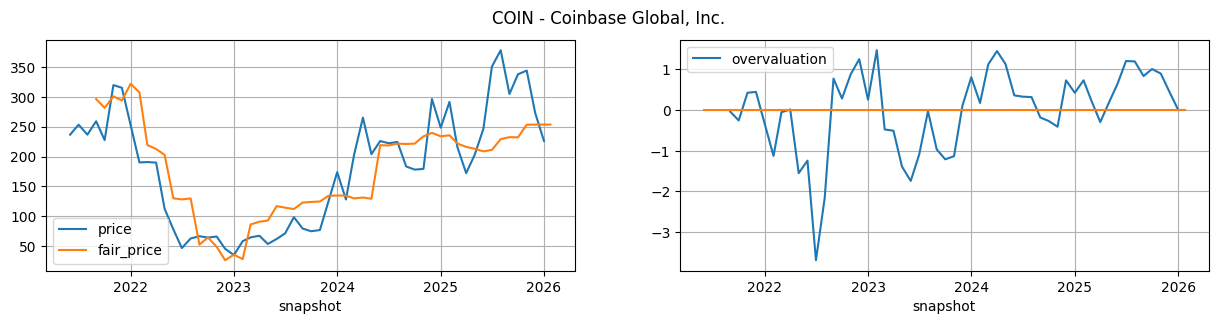

COIN fair_price = 13.262022 * (1.014792 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +28.084036


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001679788,2025-06-30,COIN,23.476038,11.381149,1.806909,1.014791,1.628610,13.262022,28.084036,15.384885,232.118723
2025-11-01,0001679788,2025-09-30,COIN,31.351367,15.328143,0.325850,1.014791,1.507706,13.262022,28.084036,16.978243,253.249881
2025-12-01,0001679788,2025-09-30,COIN,31.351367,15.328143,0.325850,1.014791,1.548493,13.262022,28.084036,16.991534,253.426139
2026-01-01,0001679788,2025-09-30,COIN,31.351367,15.328143,0.325850,1.014791,1.554836,13.262022,28.084036,16.993601,253.453548
2026-01-24,0001679788,2025-09-30,COIN,31.351367,15.328143,0.325850,1.014791,1.554836,13.262022,28.084036,16.993601,253.453548


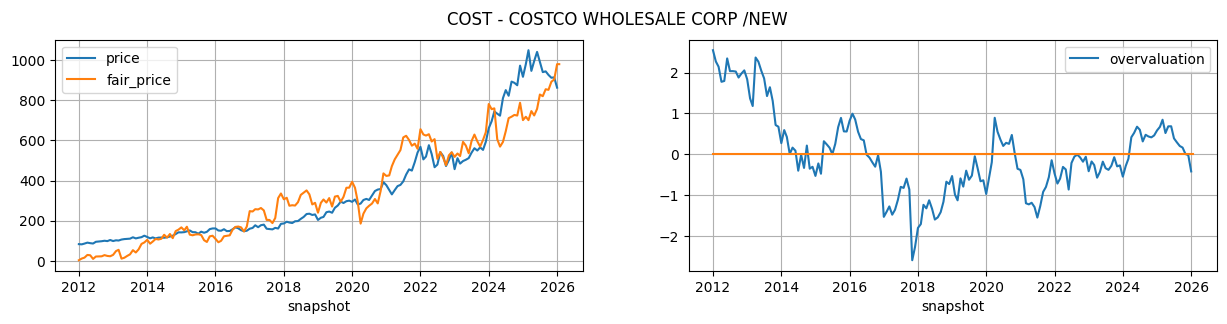

COST fair_price = 20.184331 * (1.060009 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -196.006877


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000909832,2025-05-11,COST,75.482,48.357,12.426,1.060009,1.628610,20.184331,-196.006877,51.891673,851.391825
2025-11-01,0000909832,2025-08-31,COST,77.099,47.935,13.335,1.060009,1.507706,20.184331,-196.006877,53.895859,891.844978
2025-12-01,0000909832,2025-08-31,COST,77.099,47.935,13.335,1.060009,1.548493,20.184331,-196.006877,54.439755,902.823154
2026-01-01,0000909832,2025-11-23,COST,82.790,52.487,14.763,1.060009,1.554836,20.184331,-196.006877,58.225148,979.228788
2026-01-24,0000909832,2025-11-23,COST,82.790,52.487,14.763,1.060009,1.554836,20.184331,-196.006877,58.225148,979.228788


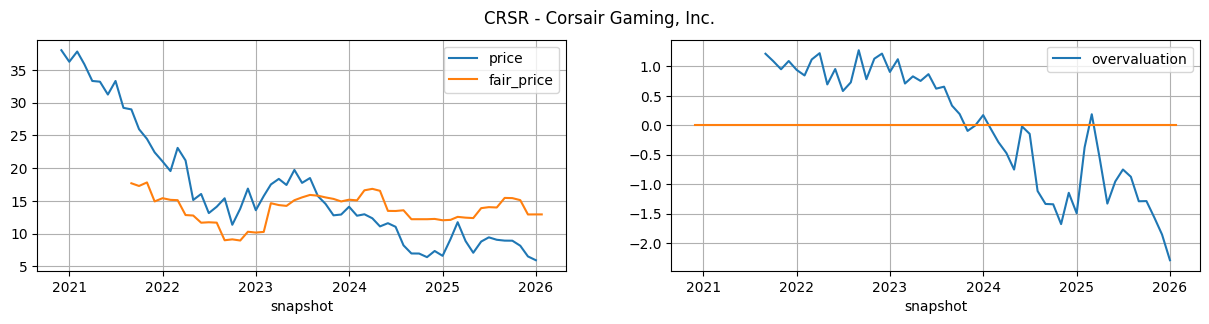

CRSR fair_price = 19.741453 * (1.690718 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -17.334183


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001743759,2025-06-30,CRSR,1.221880,0.617983,0.129599,1.690717,1.628610,19.741453,-17.334183,1.658937,15.415646
2025-11-01,0001743759,2025-06-30,CRSR,1.221880,0.617983,0.129599,1.690717,1.507706,19.741453,-17.334183,1.643268,15.106317
2025-12-01,0001743759,2025-09-30,CRSR,1.198499,0.598269,0.067507,1.690717,1.548493,19.741453,-17.334183,1.532588,12.921338
2026-01-01,0001743759,2025-09-30,CRSR,1.198499,0.598269,0.067507,1.690717,1.554836,19.741453,-17.334183,1.533016,12.929790
2026-01-24,0001743759,2025-09-30,CRSR,1.198499,0.598269,0.067507,1.690717,1.554836,19.741453,-17.334183,1.533016,12.929790


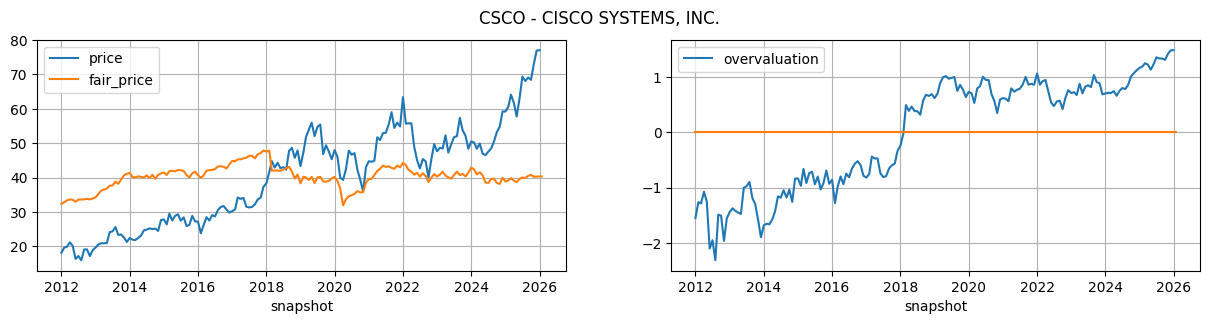

CSCO fair_price = 0.326712 * (0.726764 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +28.834385


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000858877,2025-07-26,CSCO,122.291,75.448,14.193,0.726764,1.628610,0.326712,28.834385,36.543607,40.773624
2025-11-01,0000858877,2025-07-26,CSCO,122.291,75.448,14.193,0.726764,1.507706,0.326712,28.834385,34.827617,40.212989
2025-12-01,0000858877,2025-10-25,CSCO,121.102,74.229,13.744,0.726764,1.548493,0.326712,28.834385,35.066112,40.290909
2026-01-01,0000858877,2025-10-25,CSCO,121.102,74.229,13.744,0.726764,1.554836,0.326712,28.834385,35.153285,40.319389
2026-01-24,0000858877,2025-10-25,CSCO,121.102,74.229,13.744,0.726764,1.554836,0.326712,28.834385,35.153285,40.319389


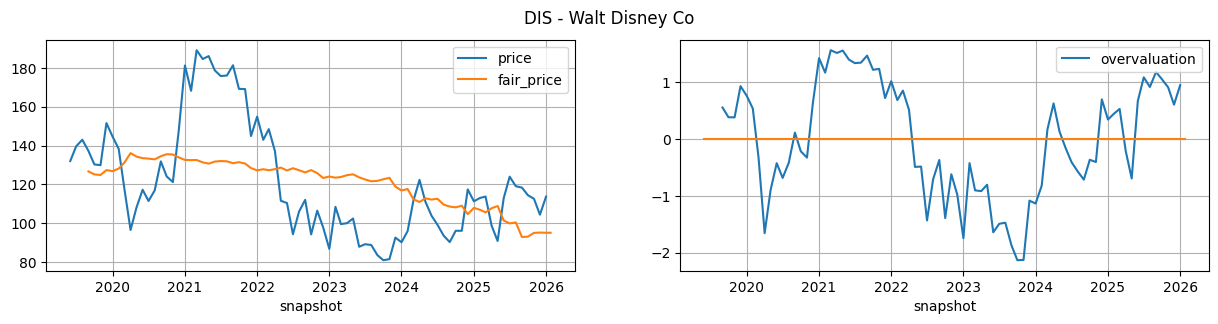

DIS fair_price = -0.833678 * (0.911482 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +195.656453


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001744489,2025-06-28,DIS,196.612,87.467,19.145,0.911482,1.628610,-0.833678,195.656453,122.921094,93.179785
2025-11-01,0001744489,2025-06-28,DIS,196.612,87.467,19.145,0.911482,1.507706,-0.833678,195.656453,120.606387,95.109506
2025-12-01,0001744489,2025-09-27,DIS,197.514,87.645,18.101,0.911482,1.548493,-0.833678,195.656453,120.414787,95.269240
2026-01-01,0001744489,2025-09-27,DIS,197.514,87.645,18.101,0.911482,1.554836,-0.833678,195.656453,120.529595,95.173527
2026-01-24,0001744489,2025-09-27,DIS,197.514,87.645,18.101,0.911482,1.554836,-0.833678,195.656453,120.529595,95.173527


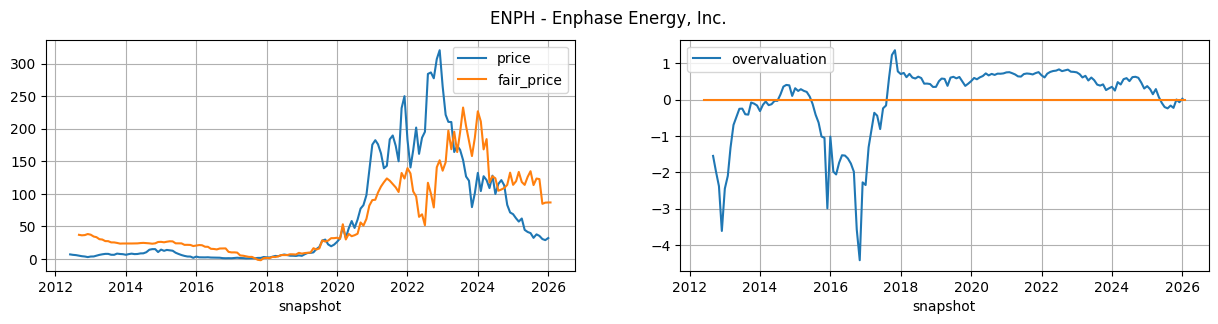

ENPH fair_price = 176.700169 * (0.688545 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +23.231489


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001463101,2025-06-30,ENPH,3.178789,2.298152,0.412473,0.688545,1.628610,176.700169,23.231489,0.562345,122.597969
2025-11-01,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,0.688545,1.507706,176.700169,23.231489,0.347194,84.580692
2025-12-01,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,0.688545,1.548493,176.700169,23.231489,0.357646,86.427530
2026-01-01,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,0.688545,1.554836,176.700169,23.231489,0.359271,86.714725
2026-01-24,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,0.688545,1.554836,176.700169,23.231489,0.359271,86.714725


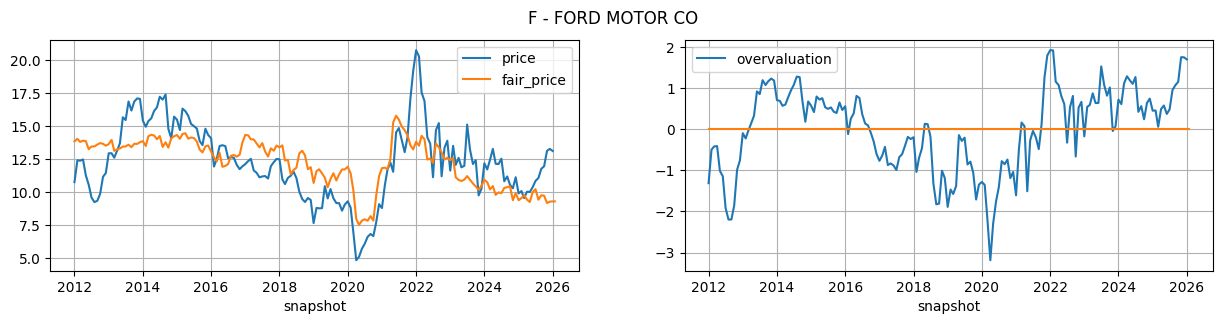

F fair_price = 0.130248 * (0.121275 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +33.434004


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000037996,2025-06-30,F,292.725,247.668,18.526,0.121275,1.628610,0.130248,33.434004,-181.996144,9.729304
2025-11-01,0000037996,2025-09-30,F,300.990,253.598,20.426,0.121275,1.507706,0.130248,33.434004,-186.299032,9.168860
2025-12-01,0000037996,2025-09-30,F,300.990,253.598,20.426,0.121275,1.548493,0.130248,33.434004,-185.465914,9.277372
2026-01-01,0000037996,2025-09-30,F,300.990,253.598,20.426,0.121275,1.554836,0.130248,33.434004,-185.336359,9.294247
2026-01-24,0000037996,2025-09-30,F,300.990,253.598,20.426,0.121275,1.554836,0.130248,33.434004,-185.336359,9.294247


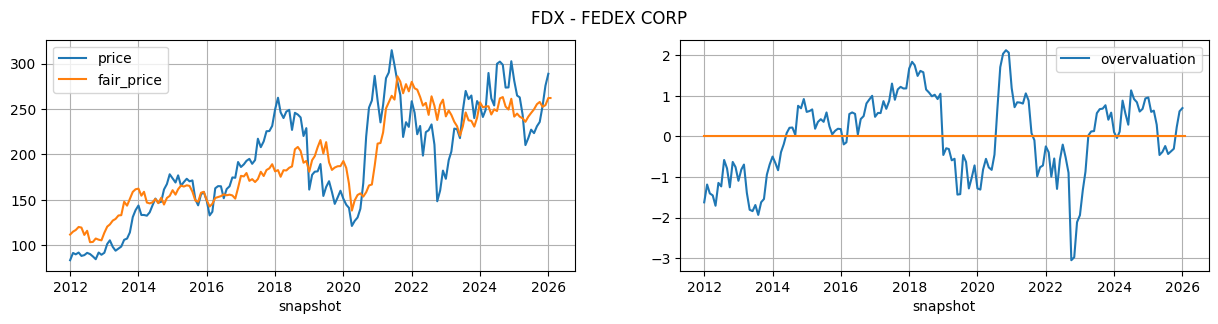

FDX fair_price = 5.836645 * (0.931388 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +59.243953


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001048911,2025-08-31,FDX,88.416,60.645,7.565,0.931388,1.628610,5.836645,59.243953,34.025018,257.835912
2025-11-01,0001048911,2025-08-31,FDX,88.416,60.645,7.565,0.931388,1.507706,5.836645,59.243953,33.110379,252.497491
2025-12-01,0001048911,2025-08-31,FDX,88.416,60.645,7.565,0.931388,1.548493,5.836645,59.243953,33.418934,254.298414
2026-01-01,0001048911,2025-11-30,FDX,89.181,61.041,8.198,0.931388,1.554836,5.836645,59.243953,34.767639,262.170326
2026-01-24,0001048911,2025-11-30,FDX,89.181,61.041,8.198,0.931388,1.554836,5.836645,59.243953,34.767639,262.170326


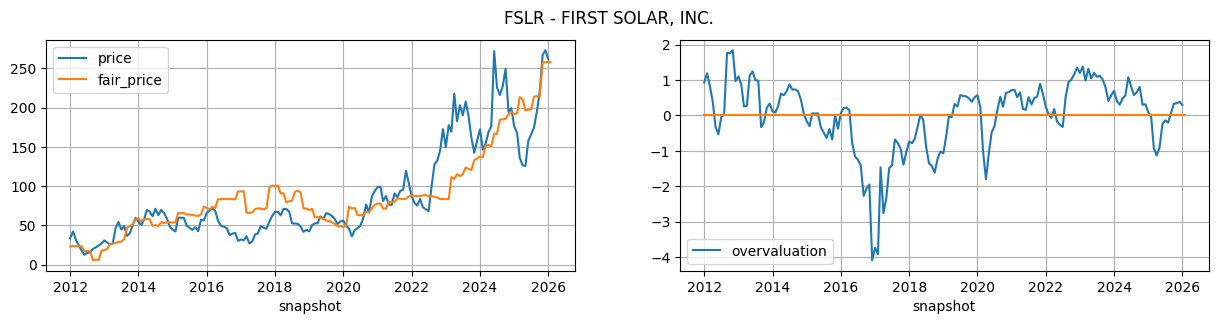

FSLR fair_price = 13.352874 * (2.261233 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -122.828223


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001274494,2025-06-30,FSLR,12.858044,4.311914,0.298857,2.261233,1.628610,13.352874,-122.828223,25.249839,214.329699
2025-11-01,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,2.261233,1.507706,13.352874,-122.828223,28.442479,256.960611
2025-12-01,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,2.261233,1.548493,13.352874,-122.828223,28.508807,257.846285
2026-01-01,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,2.261233,1.554836,13.352874,-122.828223,28.519121,257.984013
2026-01-24,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,2.261233,1.554836,13.352874,-122.828223,28.519121,257.984013


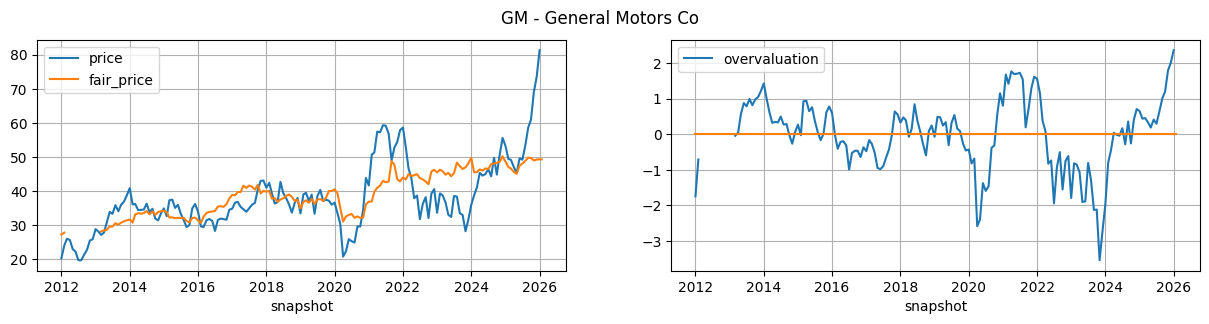

GM fair_price = 0.288329 * (0.996422 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +19.611563


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001467858,2025-06-30,GM,289.384,223.021,23.970,0.996422,1.628610,0.288329,19.611563,104.365488,49.703194
2025-11-01,0001467858,2025-09-30,GM,288.168,221.794,24.212,0.996422,1.507706,0.288329,19.611563,101.847635,48.977223
2025-12-01,0001467858,2025-09-30,GM,288.168,221.794,24.212,0.996422,1.548493,0.288329,19.611563,102.835172,49.261959
2026-01-01,0001467858,2025-09-30,GM,288.168,221.794,24.212,0.996422,1.554836,0.288329,19.611563,102.988740,49.306237
2026-01-24,0001467858,2025-09-30,GM,288.168,221.794,24.212,0.996422,1.554836,0.288329,19.611563,102.988740,49.306237


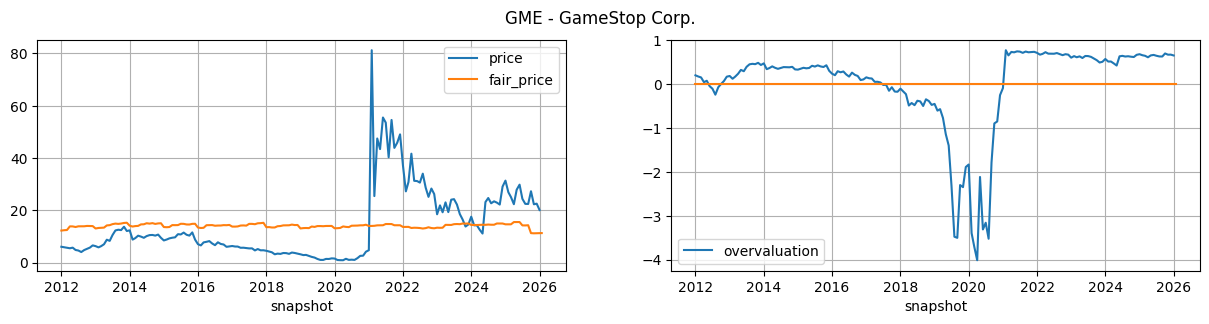

GME fair_price = 1.172720 * (0.000245 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +16.352872


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001326380,2025-08-02,GME,10.3411,5.1647,0.4968,0.000245,1.628610,1.17272,16.352872,-4.353069,11.247940
2025-11-01,0001326380,2025-08-02,GME,10.3411,5.1647,0.4968,0.000245,1.507706,1.17272,16.352872,-4.413134,11.177501
2025-12-01,0001326380,2025-08-02,GME,10.3411,5.1647,0.4968,0.000245,1.548493,1.17272,16.352872,-4.392871,11.201263
2026-01-01,0001326380,2025-11-01,GME,10.5507,5.2477,0.5835,0.000245,1.554836,1.17272,16.352872,-4.337864,11.265771
2026-01-24,0001326380,2025-11-01,GME,10.5507,5.2477,0.5835,0.000245,1.554836,1.17272,16.352872,-4.337864,11.265771


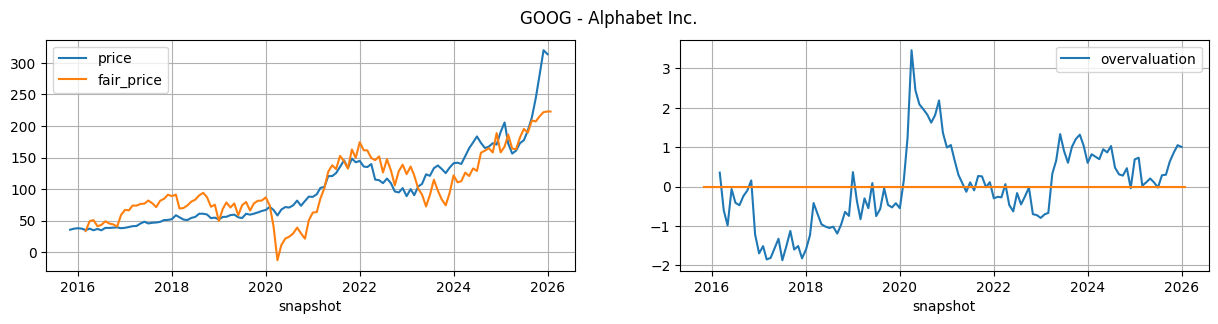

GOOG fair_price = 1.047578 * (0.229702 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +3.943506


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001652044,2025-06-30,GOOG,502.053,139.137,133.708,0.229702,1.628610,1.047578,3.943506,193.943615,207.114554
2025-11-01,0001652044,2025-09-30,GOOG,536.469,149.602,151.424,0.229702,1.507706,1.047578,3.943506,201.928723,215.479576
2025-12-01,0001652044,2025-09-30,GOOG,536.469,149.602,151.424,0.229702,1.548493,1.047578,3.943506,208.104868,221.949570
2026-01-01,0001652044,2025-09-30,GOOG,536.469,149.602,151.424,0.229702,1.554836,1.047578,3.943506,209.065298,222.955694
2026-01-24,0001652044,2025-09-30,GOOG,536.469,149.602,151.424,0.229702,1.554836,1.047578,3.943506,209.065298,222.955694


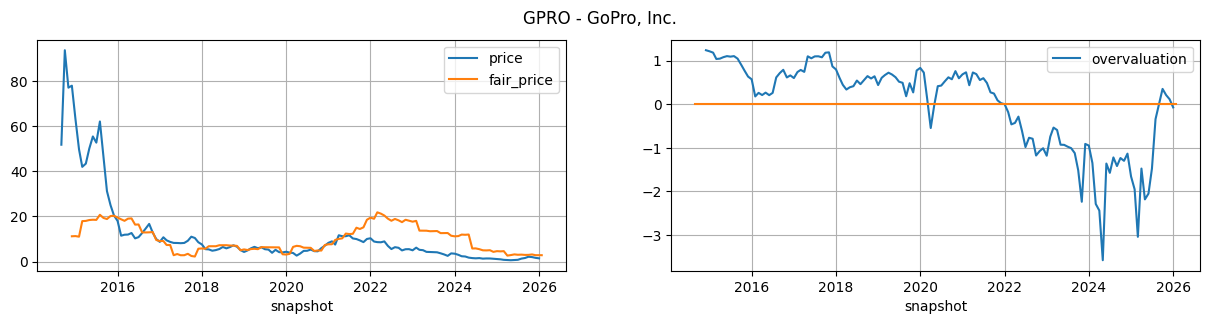

GPRO fair_price = 20.219413 * (0.821226 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +5.052450


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001500435,2025-06-30,GPRO,0.438990,0.341075,-0.075777,0.821226,1.628610,20.219413,5.05245,-0.103976,2.950111
2025-11-01,0001500435,2025-06-30,GPRO,0.438990,0.341075,-0.075777,0.821226,1.507706,20.219413,5.05245,-0.094815,3.135356
2025-12-01,0001500435,2025-09-30,GPRO,0.538608,0.458114,-0.061371,0.821226,1.548493,20.219413,5.05245,-0.110828,2.811577
2026-01-01,0001500435,2025-09-30,GPRO,0.538608,0.458114,-0.061371,0.821226,1.554836,20.219413,5.05245,-0.111217,2.803706
2026-01-24,0001500435,2025-09-30,GPRO,0.538608,0.458114,-0.061371,0.821226,1.554836,20.219413,5.05245,-0.111217,2.803706


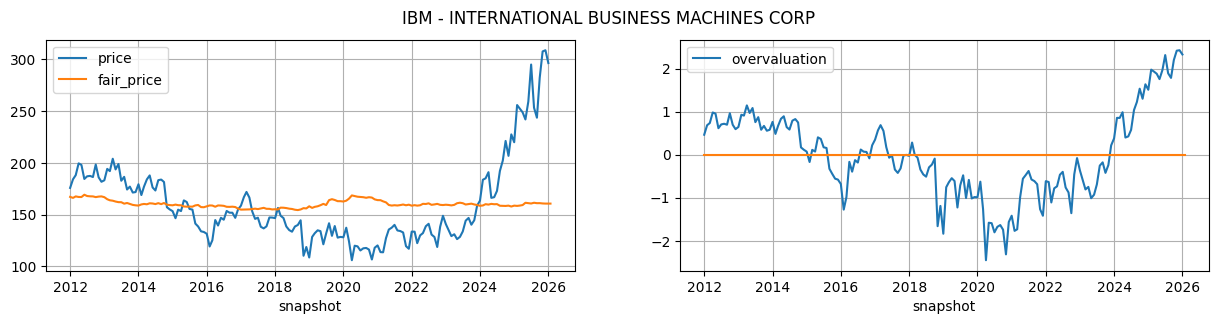

IBM fair_price = -0.224438 * (0.006428 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +138.994817


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000051143,2025-06-30,IBM,148.585,121.076,13.282,0.006428,1.628610,-0.224438,138.994817,-98.489655,161.099676
2025-11-01,0000051143,2025-09-30,IBM,146.312,118.407,13.483,0.006428,1.507706,-0.224438,138.994817,-97.138064,160.796327
2025-12-01,0000051143,2025-09-30,IBM,146.312,118.407,13.483,0.006428,1.548493,-0.224438,138.994817,-96.588132,160.672901
2026-01-01,0000051143,2025-09-30,IBM,146.312,118.407,13.483,0.006428,1.554836,-0.224438,138.994817,-96.502614,160.653708
2026-01-24,0000051143,2025-09-30,IBM,146.312,118.407,13.483,0.006428,1.554836,-0.224438,138.994817,-96.502614,160.653708


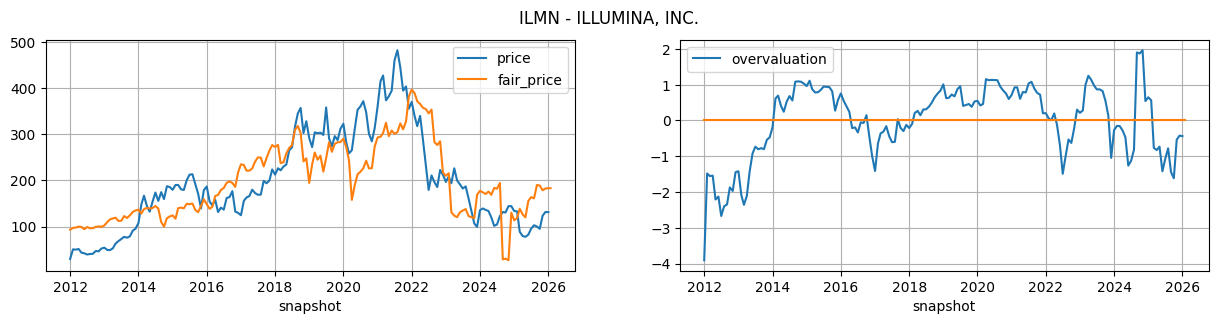

ILMN fair_price = 85.930510 * (0.395734 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +149.343294


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001110803,2025-06-29,ILMN,6.087,3.829,1.154,0.395734,1.628610,85.93051,149.343294,0.459247,188.806610
2025-11-01,0001110803,2025-09-28,ILMN,6.177,3.796,1.122,0.395734,1.507706,85.93051,149.343294,0.340093,178.567668
2025-12-01,0001110803,2025-09-28,ILMN,6.177,3.796,1.122,0.395734,1.548493,85.93051,149.343294,0.385856,182.500117
2026-01-01,0001110803,2025-09-28,ILMN,6.177,3.796,1.122,0.395734,1.554836,85.93051,149.343294,0.392973,183.111637
2026-01-24,0001110803,2025-09-28,ILMN,6.177,3.796,1.122,0.395734,1.554836,85.93051,149.343294,0.392973,183.111637


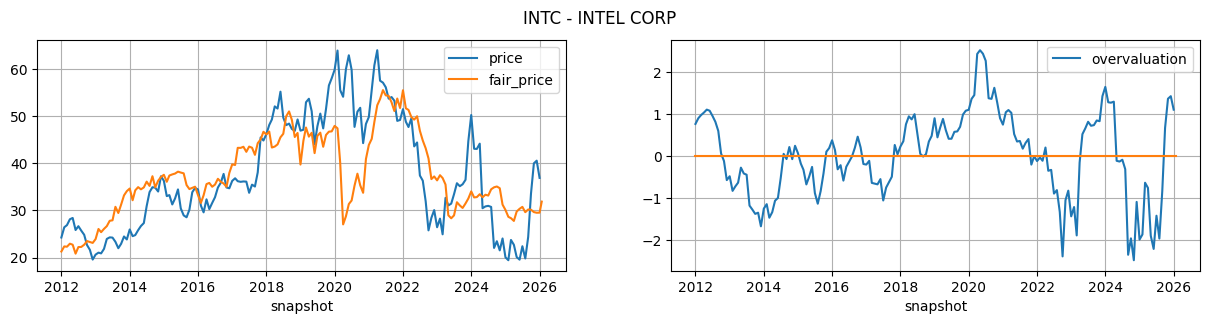

INTC fair_price = 0.412813 * (0.424260 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +28.719646


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000050863,2025-06-28,INTC,192.520,94.637,10.082,0.42426,1.628610,0.412813,28.719646,3.461141,30.148450
2025-11-01,0000050863,2025-06-28,INTC,192.520,94.637,10.082,0.42426,1.507706,0.412813,28.719646,2.242187,29.645250
2025-12-01,0000050863,2025-09-27,INTC,204.514,98.138,8.574,0.42426,1.548493,0.412813,28.719646,1.905846,29.506404
2026-01-01,0000050863,2025-09-27,INTC,204.514,98.138,8.574,0.42426,1.554836,0.412813,28.719646,1.960228,29.528854
2026-01-24,0000050863,2025-12-27,INTC,211.429,97.148,9.697,0.42426,1.554836,0.412813,28.719646,7.630065,31.869435


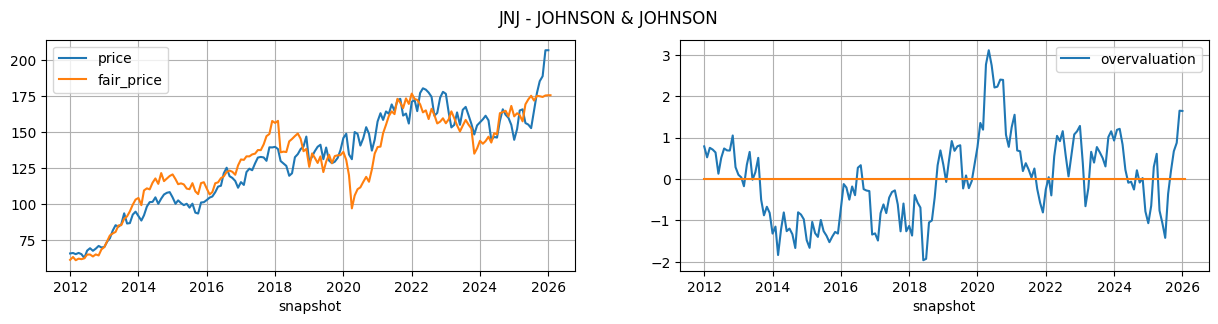

JNJ fair_price = 1.036855 * (1.465364 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -38.627594


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000200406,2025-06-29,JNJ,193.389,114.916,23.028,1.465364,1.628610,1.036855,-38.627594,205.972817,174.936443
2025-11-01,0000200406,2025-09-28,JNJ,192.816,113.539,24.204,1.465364,1.507706,1.036855,-38.627594,205.499049,174.445215
2025-12-01,0000200406,2025-09-28,JNJ,192.816,113.539,24.204,1.465364,1.548493,1.036855,-38.627594,206.486260,175.468810
2026-01-01,0000200406,2025-09-28,JNJ,192.816,113.539,24.204,1.465364,1.554836,1.036855,-38.627594,206.639778,175.627985
2026-01-24,0000200406,2025-09-28,JNJ,192.816,113.539,24.204,1.465364,1.554836,1.036855,-38.627594,206.639778,175.627985


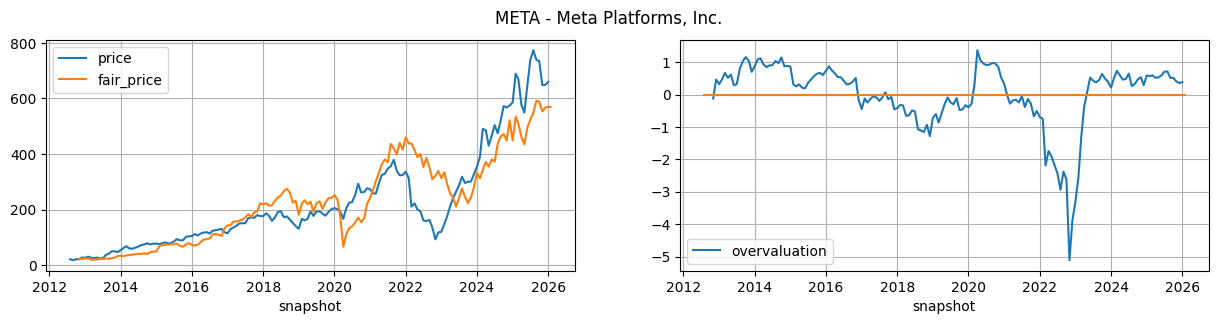

META fair_price = 3.160840 * (0.387273 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +15.748079


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001326801,2025-06-30,META,294.744,99.674,102.299,0.387273,1.628610,3.16084,15.748079,181.077515,588.105044
2025-11-01,0001326801,2025-09-30,META,303.844,109.778,107.574,0.387273,1.507706,3.16084,15.748079,170.082492,553.351541
2025-12-01,0001326801,2025-09-30,META,303.844,109.778,107.574,0.387273,1.548493,3.16084,15.748079,174.470124,567.220141
2026-01-01,0001326801,2025-09-30,META,303.844,109.778,107.574,0.387273,1.554836,3.16084,15.748079,175.152428,569.376795
2026-01-24,0001326801,2025-09-30,META,303.844,109.778,107.574,0.387273,1.554836,3.16084,15.748079,175.152428,569.376795


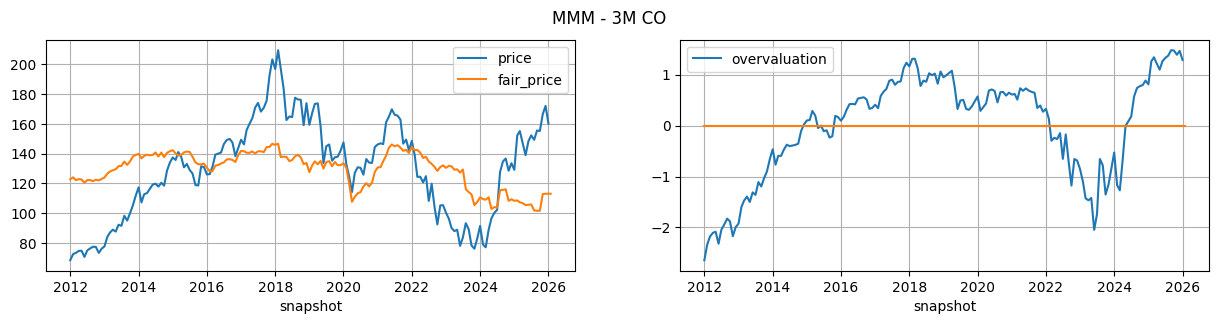

MMM fair_price = 1.871130 * (0.468015 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +134.418807


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000066740,2025-06-30,MMM,37.989,33.699,-1.002,0.468015,1.628610,1.87113,134.418807,-17.551435,101.577794
2025-11-01,0000066740,2025-09-30,MMM,37.611,32.983,2.541,0.468015,1.507706,1.87113,134.418807,-11.549396,112.808388
2025-12-01,0000066740,2025-09-30,MMM,37.611,32.983,2.541,0.468015,1.548493,1.87113,134.418807,-11.445756,113.002312
2026-01-01,0000066740,2025-09-30,MMM,37.611,32.983,2.541,0.468015,1.554836,1.87113,134.418807,-11.429639,113.032469
2026-01-24,0000066740,2025-09-30,MMM,37.611,32.983,2.541,0.468015,1.554836,1.87113,134.418807,-11.429639,113.032469


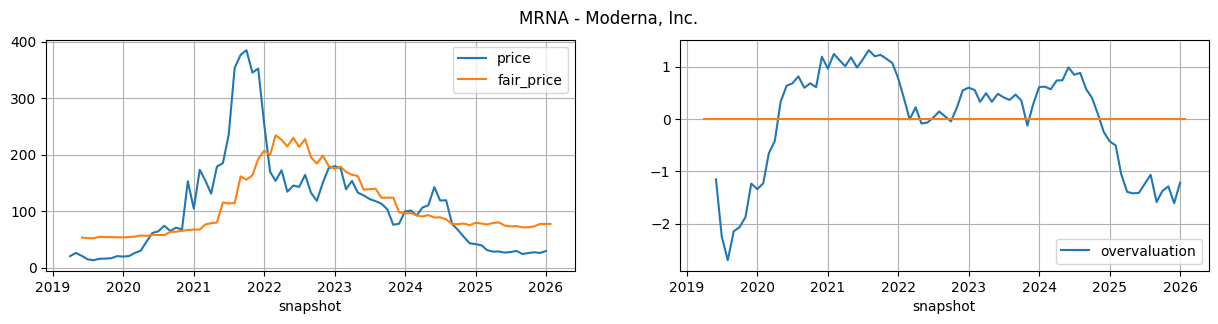

MRNA fair_price = 4.748535 * (0.931145 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +51.639005


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001682852,2025-06-30,MRNA,12.010,2.611,-2.697,0.931145,1.628610,4.748535,51.639005,4.179686,71.486391
2025-11-01,0001682852,2025-06-30,MRNA,12.010,2.611,-2.697,0.931145,1.507706,4.748535,51.639005,4.505764,73.034784
2025-12-01,0001682852,2025-09-30,MRNA,12.135,2.805,-1.978,0.931145,1.548493,4.748535,51.639005,5.431521,77.430773
2026-01-01,0001682852,2025-09-30,MRNA,12.135,2.805,-1.978,0.931145,1.554836,4.748535,51.639005,5.418976,77.371199
2026-01-24,0001682852,2025-09-30,MRNA,12.135,2.805,-1.978,0.931145,1.554836,4.748535,51.639005,5.418976,77.371199


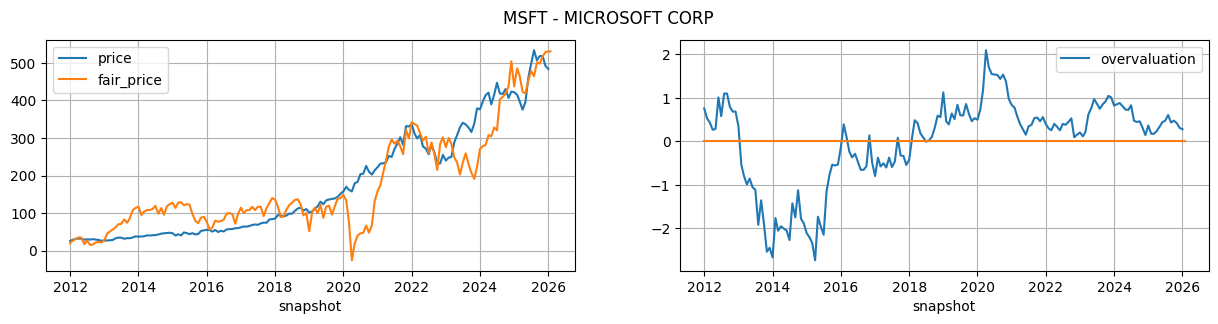

MSFT fair_price = 1.965829 * (0.423501 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +88.368262


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000789019,2025-06-30,MSFT,619.003,275.524,136.162,0.423501,1.628610,1.965829,88.368262,208.378935,498.005679
2025-11-01,0000789019,2025-09-30,MSFT,636.351,273.275,147.039,0.423501,1.507706,1.965829,88.368262,217.911617,516.745304
2025-12-01,0000789019,2025-09-30,MSFT,636.351,273.275,147.039,0.423501,1.548493,1.965829,88.368262,223.908911,528.534961
2026-01-01,0000789019,2025-09-30,MSFT,636.351,273.275,147.039,0.423501,1.554836,1.965829,88.368262,224.841528,530.368326
2026-01-24,0000789019,2025-09-30,MSFT,636.351,273.275,147.039,0.423501,1.554836,1.965829,88.368262,224.841528,530.368326


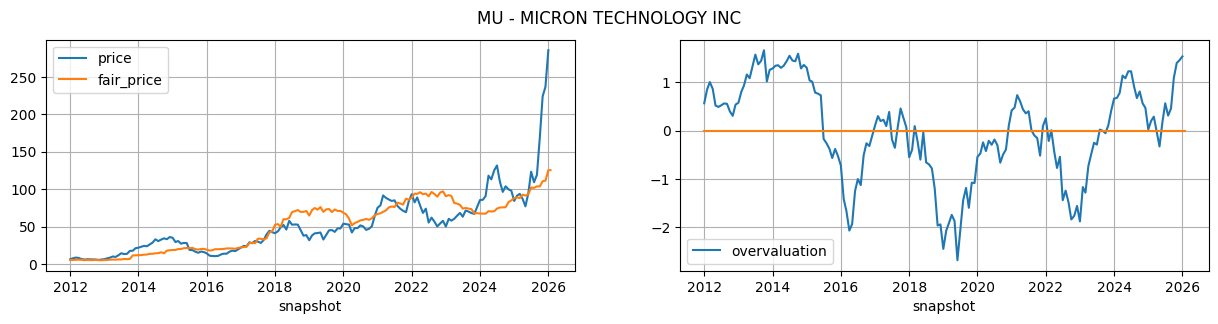

MU fair_price = 0.981234 * (1.474216 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -7.079075


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000723125,2025-05-29,MU,78.397,27.649,15.200,1.474216,1.628610,0.981234,-7.079075,112.679957,103.486297
2025-11-01,0000723125,2025-08-28,MU,82.798,28.633,17.525,1.474216,1.507706,0.981234,-7.079075,119.851656,110.523410
2025-12-01,0000723125,2025-08-28,MU,82.798,28.633,17.525,1.474216,1.548493,0.981234,-7.079075,120.566450,111.224790
2026-01-01,0000723125,2025-11-27,MU,85.971,27.165,22.692,1.474216,1.554836,0.981234,-7.079075,134.857128,125.247285
2026-01-24,0000723125,2025-11-27,MU,85.971,27.165,22.692,1.474216,1.554836,0.981234,-7.079075,134.857128,125.247285


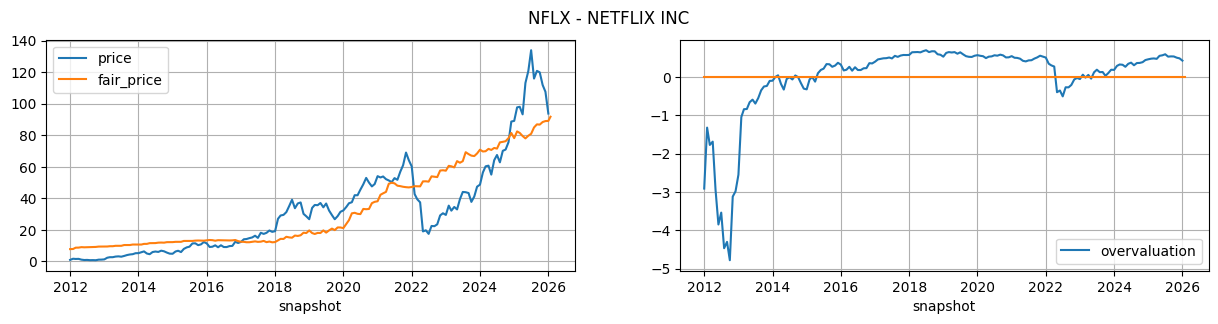

NFLX fair_price = 1.570633 * (1.205332 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +7.228996


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001065280,2025-06-30,NFLX,53.099664,28.147765,9.070452,1.205332,1.628610,1.570633,7.228996,50.627166,86.745690
2025-11-01,0001065280,2025-09-30,NFLX,54.934835,28.980800,9.574525,1.205332,1.507706,1.570633,7.228996,51.669461,88.382753
2025-12-01,0001065280,2025-09-30,NFLX,54.934835,28.980800,9.574525,1.205332,1.548493,1.570633,7.228996,52.059978,88.996112
2026-01-01,0001065280,2025-09-30,NFLX,54.934835,28.980800,9.574525,1.205332,1.554836,1.570633,7.228996,52.120706,89.091493
2026-01-24,0001065280,2025-12-31,NFLX,55.596993,28.981505,10.149273,1.205332,1.554836,1.570633,7.228996,53.811760,91.747518


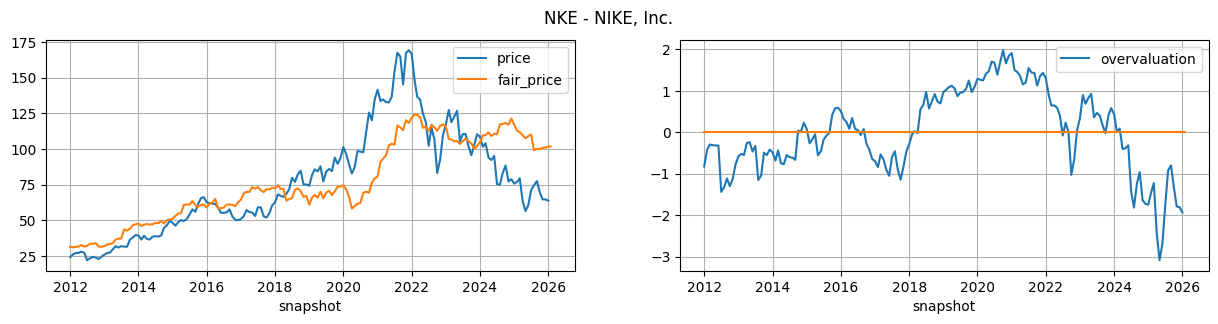

NKE fair_price = 2.024572 * (2.036619 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -15.732111


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000320187,2025-05-31,NKE,36.579,23.366,3.698,2.036619,1.628610,2.024572,-15.732111,57.154085,99.980454
2025-11-01,0000320187,2025-08-31,NKE,37.334,23.866,3.526,2.036619,1.507706,2.024572,-15.732111,57.485304,100.651031
2025-12-01,0000320187,2025-08-31,NKE,37.334,23.866,3.526,2.036619,1.548493,2.024572,-15.732111,57.629119,100.942195
2026-01-01,0000320187,2025-11-30,NKE,37.787,23.702,3.056,2.036619,1.554836,2.024572,-15.732111,58.007299,101.707847
2026-01-24,0000320187,2025-11-30,NKE,37.787,23.702,3.056,2.036619,1.554836,2.024572,-15.732111,58.007299,101.707847


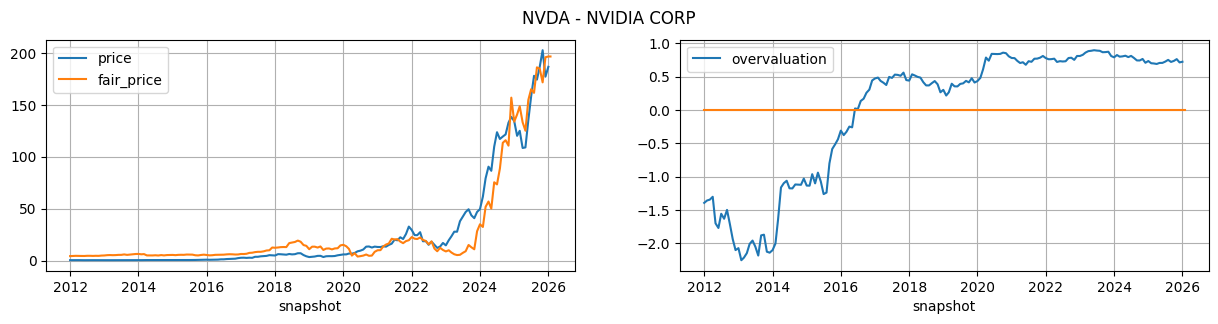

NVDA fair_price = 1.410672 * (0.301024 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +5.229958


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001045810,2025-07-27,NVDA,140.740,40.609,77.035,0.301024,1.628610,1.410672,5.229958,127.217165,184.691600
2025-11-01,0001045810,2025-07-27,NVDA,140.740,40.609,77.035,0.301024,1.507706,1.410672,5.229958,117.903328,171.552835
2025-12-01,0001045810,2025-10-26,NVDA,161.148,42.251,83.159,0.301024,1.548493,1.410672,5.229958,135.029642,195.712440
2026-01-01,0001045810,2025-10-26,NVDA,161.148,42.251,83.159,0.301024,1.554836,1.410672,5.229958,135.557091,196.456496
2026-01-24,0001045810,2025-10-26,NVDA,161.148,42.251,83.159,0.301024,1.554836,1.410672,5.229958,135.557091,196.456496


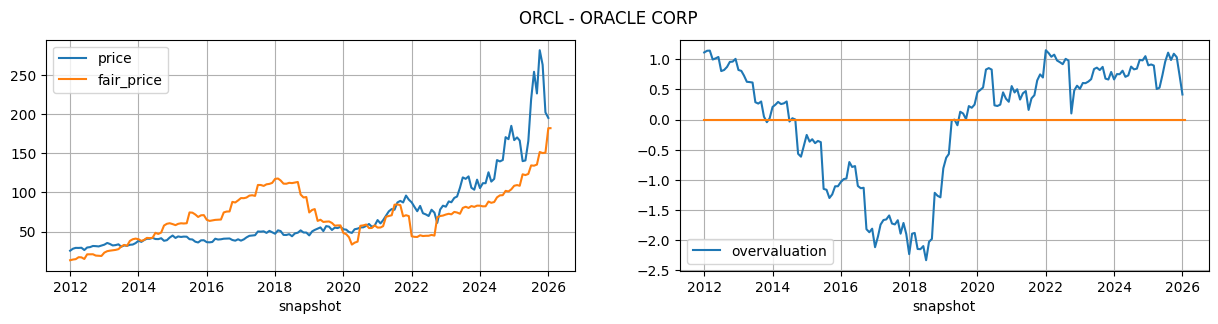

ORCL fair_price = 0.512345 * (3.198818 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -82.161442


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001341439,2025-08-31,ORCL,180.449,156.295,21.534,3.198818,1.628610,0.512345,-82.161442,455.998951,151.467390
2025-11-01,0001341439,2025-08-31,ORCL,180.449,156.295,21.534,3.198818,1.507706,0.512345,-82.161442,453.395405,150.133476
2025-12-01,0001341439,2025-08-31,ORCL,180.449,156.295,21.534,3.198818,1.548493,0.512345,-82.161442,454.273715,150.583473
2026-01-01,0001341439,2025-11-30,ORCL,204.984,175.033,22.296,3.198818,1.554836,0.512345,-82.161442,515.340075,181.870524
2026-01-24,0001341439,2025-11-30,ORCL,204.984,175.033,22.296,3.198818,1.554836,0.512345,-82.161442,515.340075,181.870524


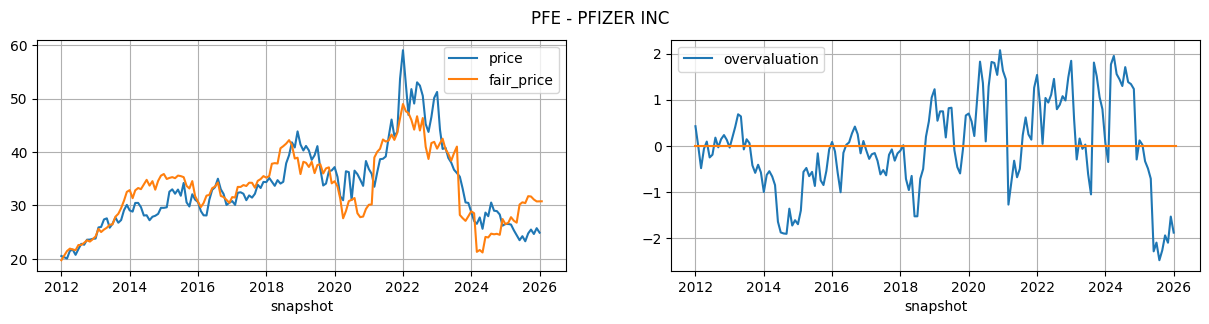

PFE fair_price = 0.308881 * (0.007419 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +59.822387


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000078003,2025-06-29,PFE,206.095,117.40,15.188,0.007419,1.628610,0.308881,59.822387,-91.135702,31.672258
2025-11-01,0000078003,2025-06-29,PFE,206.095,117.40,15.188,0.007419,1.507706,0.308881,59.822387,-92.971991,31.105062
2025-12-01,0000078003,2025-09-28,PFE,208.731,115.93,13.077,0.007419,1.548493,0.308881,59.822387,-94.131830,30.746809
2026-01-01,0000078003,2025-09-28,PFE,208.731,115.93,13.077,0.007419,1.554836,0.308881,59.822387,-94.048887,30.772429
2026-01-24,0000078003,2025-09-28,PFE,208.731,115.93,13.077,0.007419,1.554836,0.308881,59.822387,-94.048887,30.772429


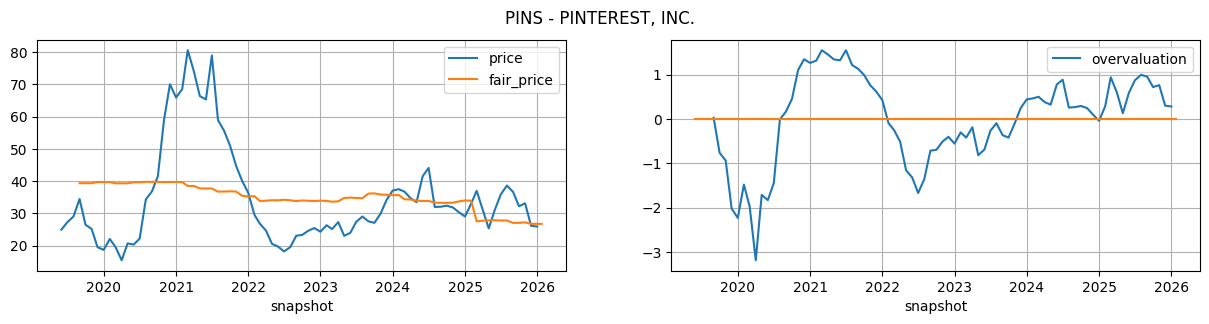

PINS fair_price = -1.137061 * (3.076236 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +47.248119


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001506293,2025-06-30,PINS,5.402987,0.591034,1.073421,3.076236,1.628610,-1.137061,47.248119,17.778015,27.033439
2025-11-01,0001506293,2025-06-30,PINS,5.402987,0.591034,1.073421,3.076236,1.507706,-1.137061,47.248119,17.648234,27.181007
2025-12-01,0001506293,2025-09-30,PINS,5.515410,0.690442,1.147046,3.076236,1.548493,-1.137061,47.248119,18.052455,26.721383
2026-01-01,0001506293,2025-09-30,PINS,5.515410,0.690442,1.147046,3.076236,1.554836,-1.137061,47.248119,18.059730,26.713111
2026-01-24,0001506293,2025-09-30,PINS,5.515410,0.690442,1.147046,3.076236,1.554836,-1.137061,47.248119,18.059730,26.713111


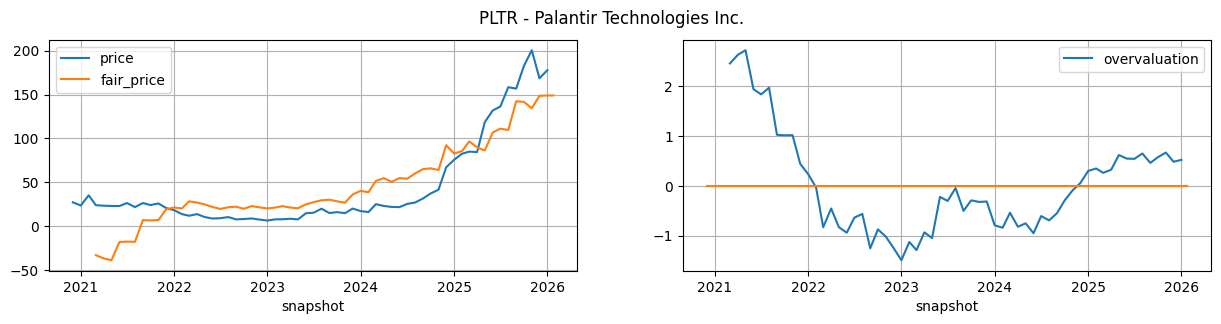

PLTR fair_price = 34.390654 * (0.387631 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -4.039069


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001321655,2025-06-30,PLTR,7.365688,1.436787,1.729613,0.387631,1.628610,34.390654,-4.039069,4.235250,141.613937
2025-11-01,0001321655,2025-06-30,PLTR,7.365688,1.436787,1.729613,0.387631,1.507706,34.390654,-4.039069,4.026133,134.422264
2025-12-01,0001321655,2025-09-30,PLTR,8.113960,1.523503,1.817505,0.387631,1.548493,34.390654,-4.039069,4.436116,148.521873
2026-01-01,0001321655,2025-09-30,PLTR,8.113960,1.523503,1.817505,0.387631,1.554836,34.390654,-4.039069,4.447644,148.918321
2026-01-24,0001321655,2025-09-30,PLTR,8.113960,1.523503,1.817505,0.387631,1.554836,34.390654,-4.039069,4.447644,148.918321


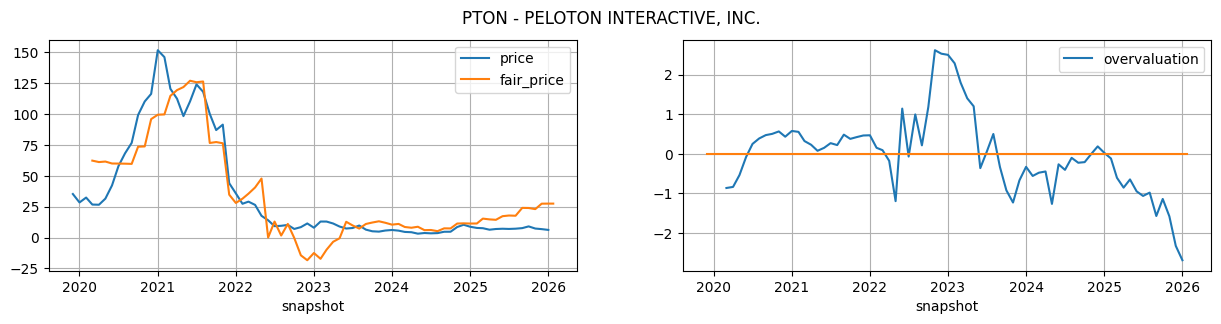

PTON fair_price = 22.759329 * (1.485907 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -2.525172


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001639825,2025-06-30,PTON,2.1253,2.5391,0.3330,1.485907,1.628610,22.759329,-2.525172,1.161225,23.903535
2025-11-01,0001639825,2025-06-30,PTON,2.1253,2.5391,0.3330,1.485907,1.507706,22.759329,-2.525172,1.120964,22.987221
2025-12-01,0001639825,2025-09-30,PTON,2.1701,2.5171,0.3924,1.485907,1.548493,22.759329,-2.525172,1.315095,27.405518
2026-01-01,0001639825,2025-09-30,PTON,2.1701,2.5171,0.3924,1.485907,1.554836,22.759329,-2.525172,1.317584,27.462163
2026-01-24,0001639825,2025-09-30,PTON,2.1701,2.5171,0.3924,1.485907,1.554836,22.759329,-2.525172,1.317584,27.462163


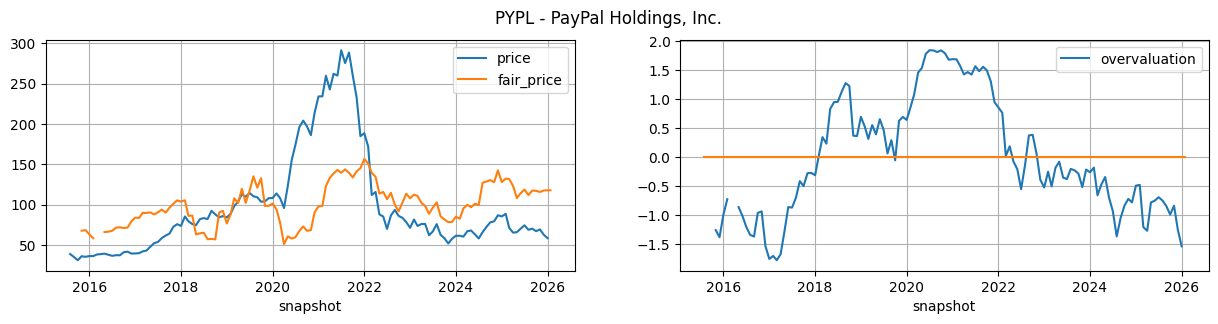

PYPL fair_price = 6.831400 * (0.862882 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -13.716717


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001633917,2025-06-30,PYPL,79.777,59.576,6.066,0.862882,1.628610,6.8314,-13.716717,19.141259,117.044875
2025-11-01,0001633917,2025-09-30,PYPL,79.801,59.603,6.426,0.862882,1.507706,6.8314,-13.716717,18.944339,115.699635
2025-12-01,0001633917,2025-09-30,PYPL,79.801,59.603,6.426,0.862882,1.548493,6.8314,-13.716717,19.206437,117.490131
2026-01-01,0001633917,2025-09-30,PYPL,79.801,59.603,6.426,0.862882,1.554836,6.8314,-13.716717,19.247195,117.768564
2026-01-24,0001633917,2025-09-30,PYPL,79.801,59.603,6.426,0.862882,1.554836,6.8314,-13.716717,19.247195,117.768564


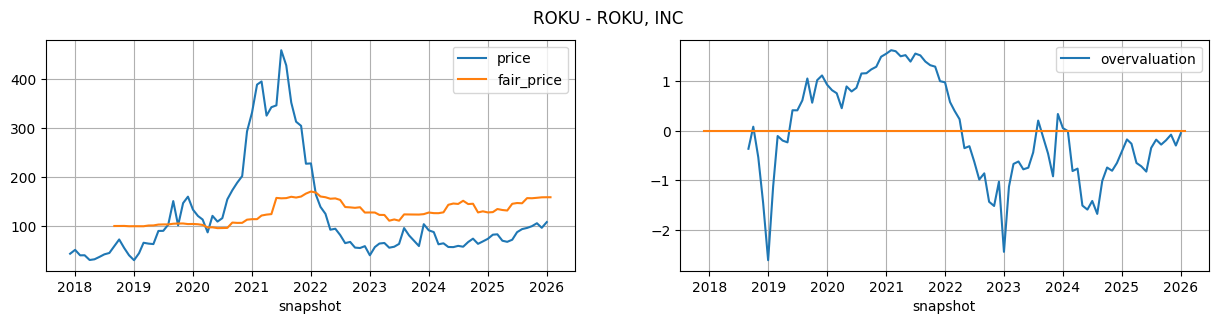

ROKU fair_price = 53.255291 * (0.494946 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +99.958220


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001428439,2025-06-30,ROKU,4.281955,1.691403,0.396421,0.494946,1.628610,53.255291,99.95822,1.073549,157.130379
2025-11-01,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,0.494946,1.507706,53.255291,99.95822,1.090769,158.047432
2025-12-01,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,0.494946,1.548493,53.255291,99.95822,1.109342,159.036533
2026-01-01,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,0.494946,1.554836,53.255291,99.95822,1.112230,159.190344
2026-01-24,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,0.494946,1.554836,53.255291,99.95822,1.112230,159.190344


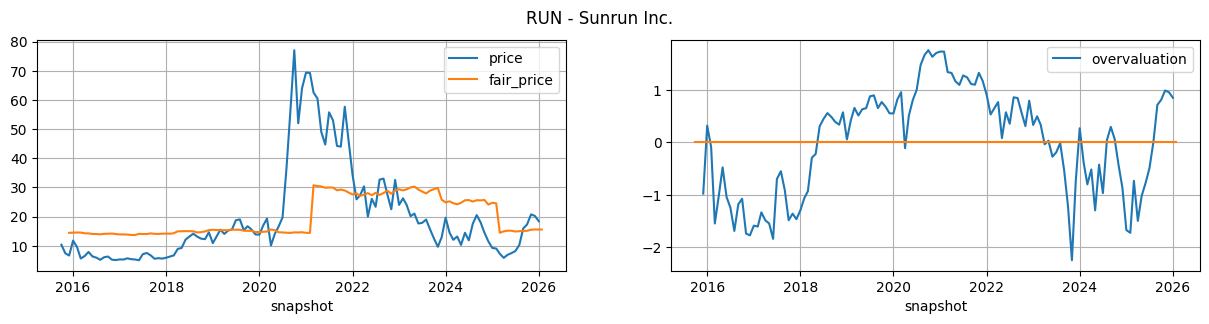

RUN fair_price = 3.622697 * (0.951457 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +13.049670


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001469367,2025-06-30,RUN,21.230135,18.303408,-0.811380,0.951457,1.628610,3.622697,13.04967,0.574735,15.131761
2025-11-01,0001469367,2025-06-30,RUN,21.230135,18.303408,-0.811380,0.951457,1.507706,3.622697,13.04967,0.672834,15.487144
2025-12-01,0001469367,2025-09-30,RUN,22.225482,19.241580,-0.776747,0.951457,1.548493,3.622697,13.04967,0.702227,15.593627
2026-01-01,0001469367,2025-09-30,RUN,22.225482,19.241580,-0.776747,0.951457,1.554836,3.622697,13.04967,0.697301,15.575779
2026-01-24,0001469367,2025-09-30,RUN,22.225482,19.241580,-0.776747,0.951457,1.554836,3.622697,13.04967,0.697301,15.575779


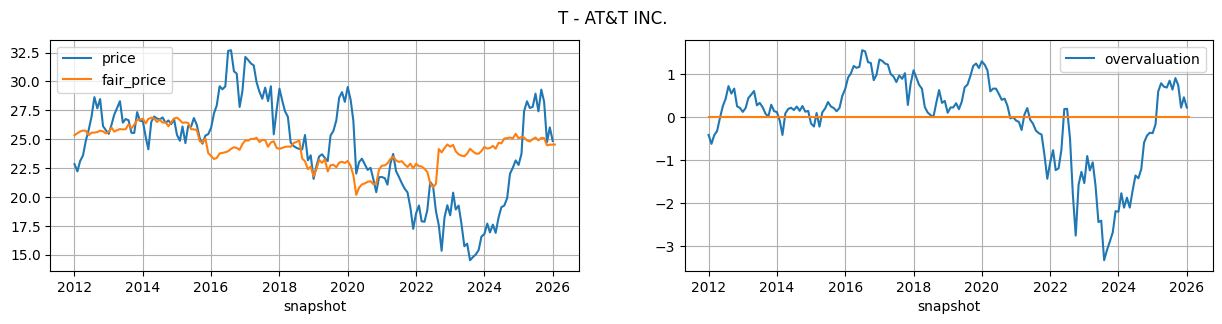

T fair_price = 0.036922 * (0.024888 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +32.744276


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000732717,2025-06-30,T,405.491,284.097,40.943,0.024888,1.628610,0.036922,32.744276,-207.324758,25.089445
2025-11-01,0000732717,2025-09-30,T,423.213,296.458,40.860,0.024888,1.507706,0.036922,32.744276,-224.319995,24.461948
2025-12-01,0000732717,2025-09-30,T,423.213,296.458,40.860,0.024888,1.548493,0.036922,32.744276,-222.653434,24.523481
2026-01-01,0000732717,2025-09-30,T,423.213,296.458,40.860,0.024888,1.554836,0.036922,32.744276,-222.394274,24.533049
2026-01-24,0000732717,2025-09-30,T,423.213,296.458,40.860,0.024888,1.554836,0.036922,32.744276,-222.394274,24.533049


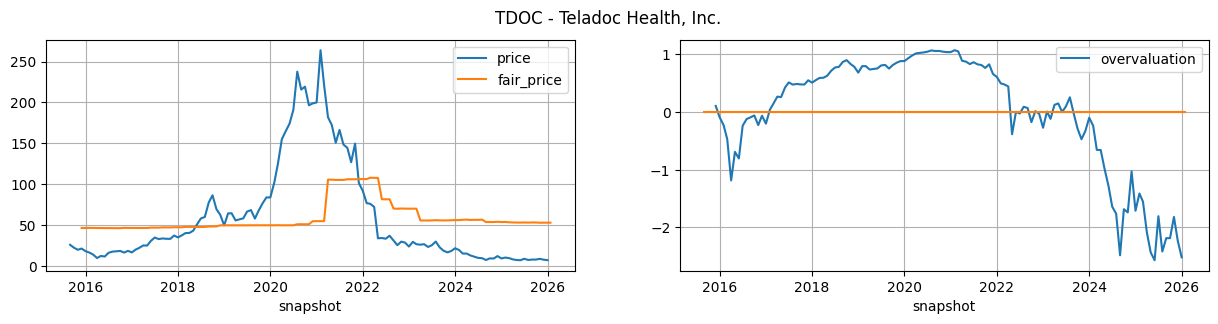

TDOC fair_price = 3.651957 * (1.032039 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +45.769979


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001477449,2025-06-30,TDOC,2.894004,1.471865,0.303428,1.032039,1.628610,3.651957,45.769979,2.009026,53.106854
2025-11-01,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,1.032039,1.507706,3.651957,45.769979,1.925370,52.801348
2025-12-01,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,1.032039,1.548493,3.651957,45.769979,1.937301,52.844919
2026-01-01,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,1.032039,1.554836,3.651957,45.769979,1.939156,52.851695
2026-01-24,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,1.032039,1.554836,3.651957,45.769979,1.939156,52.851695


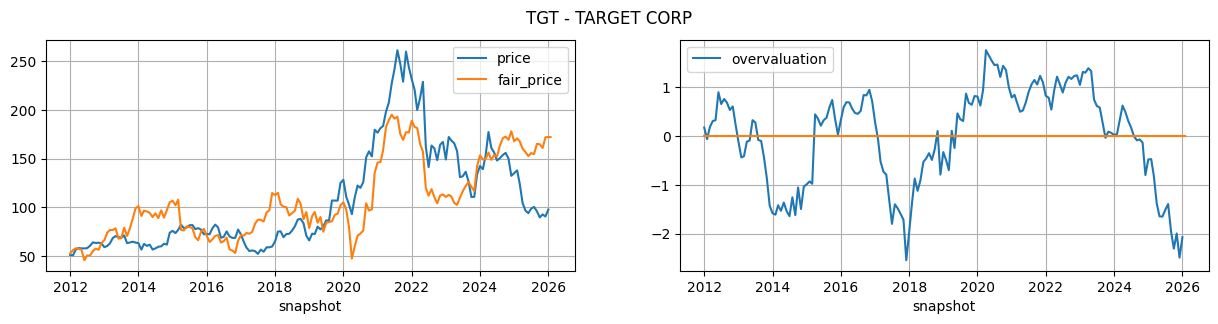

TGT fair_price = 4.984921 * (1.589906 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -134.134694


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000027419,2025-08-02,TGT,57.851,42.431,6.386,1.589906,1.628610,4.984921,-134.134694,59.946962,164.696152
2025-11-01,0000027419,2025-08-02,TGT,57.851,42.431,6.386,1.589906,1.507706,4.984921,-134.134694,59.174869,160.847331
2025-12-01,0000027419,2025-11-01,TGT,59.991,44.490,6.774,1.589906,1.548493,4.984921,-134.134694,61.379550,171.837490
2026-01-01,0000027419,2025-11-01,TGT,59.991,44.490,6.774,1.589906,1.554836,4.984921,-134.134694,61.422515,172.051667
2026-01-24,0000027419,2025-11-01,TGT,59.991,44.490,6.774,1.589906,1.554836,4.984921,-134.134694,61.422515,172.051667


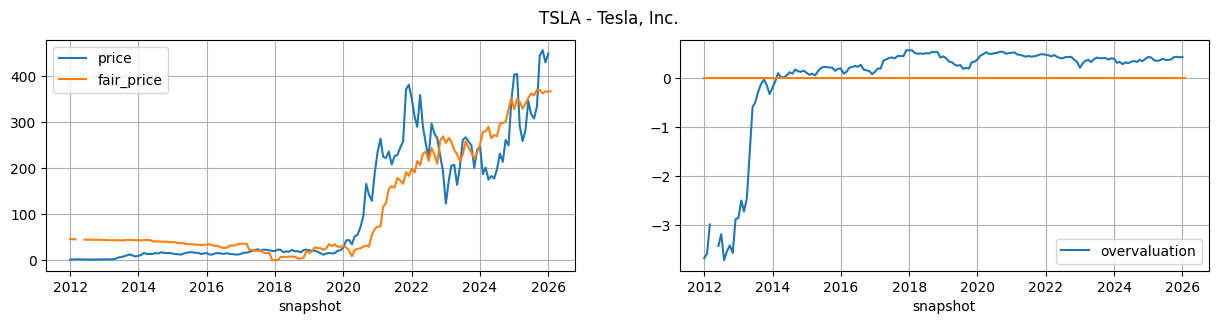

TSLA fair_price = 5.822177 * (0.632936 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +44.898938


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001318605,2025-06-30,TSLA,128.567,51.253,15.765,0.632936,1.628610,5.822177,44.898938,55.796745,369.757487
2025-11-01,0001318605,2025-09-30,TSLA,133.735,53.765,15.748,0.632936,1.507706,5.822177,44.898938,54.624077,362.930006
2025-12-01,0001318605,2025-09-30,TSLA,133.735,53.765,15.748,0.632936,1.548493,5.822177,44.898938,55.266392,366.669680
2026-01-01,0001318605,2025-09-30,TSLA,133.735,53.765,15.748,0.632936,1.554836,5.822177,44.898938,55.366276,367.251222
2026-01-24,0001318605,2025-09-30,TSLA,133.735,53.765,15.748,0.632936,1.554836,5.822177,44.898938,55.366276,367.251222


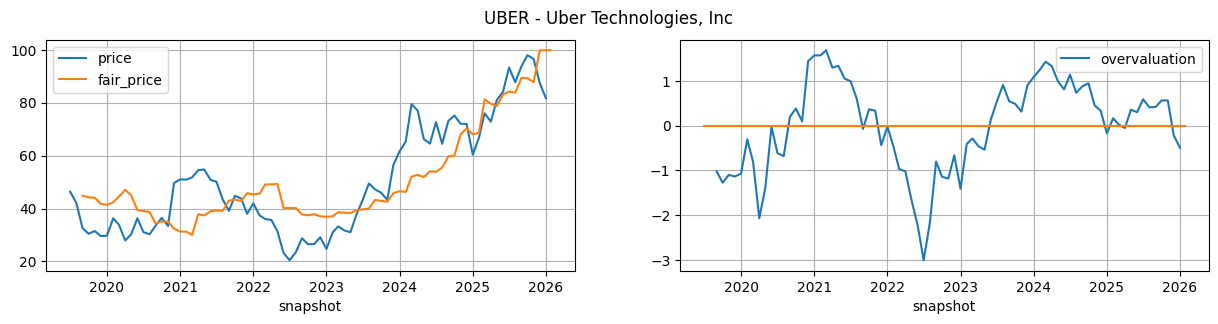

UBER fair_price = 1.370768 * (1.348775 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +11.881412


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001543151,2025-06-30,UBER,55.982,33.384,8.789,1.348775,1.628610,1.370768,11.881412,56.436978,89.243411
2025-11-01,0001543151,2025-06-30,UBER,55.982,33.384,8.789,1.348775,1.507706,1.370768,11.881412,55.374353,87.786798
2025-12-01,0001543151,2025-09-30,UBER,63.344,35.210,8.966,1.348775,1.548493,1.370768,11.881412,64.110596,99.762160
2026-01-01,0001543151,2025-09-30,UBER,63.344,35.210,8.966,1.348775,1.554836,1.370768,11.881412,64.167464,99.840113
2026-01-24,0001543151,2025-09-30,UBER,63.344,35.210,8.966,1.348775,1.554836,1.370768,11.881412,64.167464,99.840113


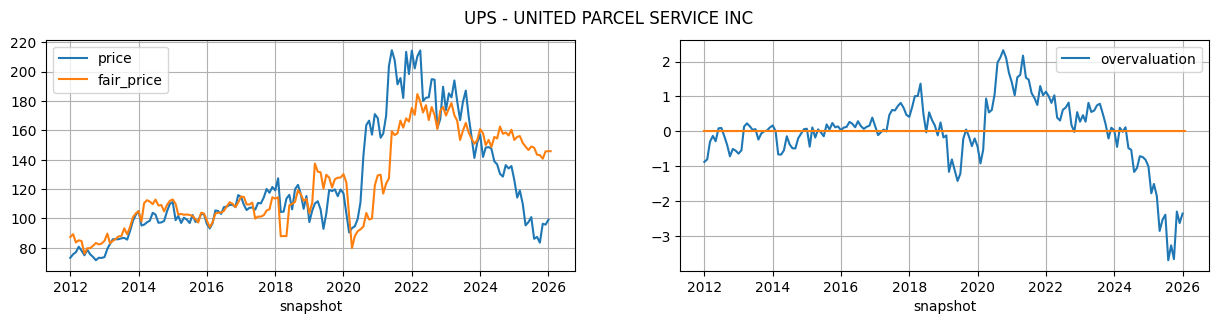

UPS fair_price = 2.718551 * (0.836242 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +98.834038


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001090727,2025-06-30,UPS,70.923,55.173,7.479,0.836241,1.628610,2.718551,98.834038,16.316130,143.190263
2025-11-01,0001090727,2025-06-30,UPS,70.923,55.173,7.479,0.836241,1.507706,2.718551,98.834038,15.411889,140.732038
2025-12-01,0001090727,2025-09-30,UPS,71.392,55.569,8.463,0.836241,1.548493,2.718551,98.834038,17.236851,145.693288
2026-01-01,0001090727,2025-09-30,UPS,71.392,55.569,8.463,0.836241,1.554836,2.718551,98.834038,17.290528,145.839214
2026-01-24,0001090727,2025-09-30,UPS,71.392,55.569,8.463,0.836241,1.554836,2.718551,98.834038,17.290528,145.839214


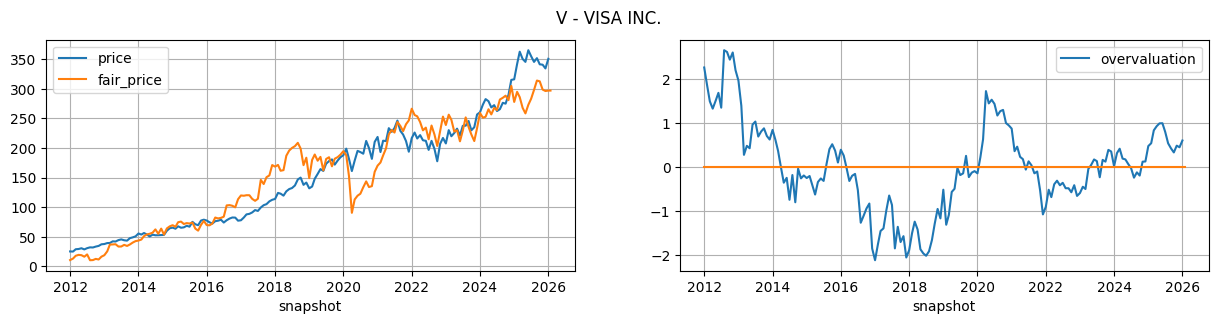

V fair_price = 4.883959 * (1.103240 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -113.451608


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001403161,2025-06-30,V,100.024,61.360,23.485,1.10324,1.628610,4.883959,-113.451608,87.238424,312.617267
2025-11-01,0001403161,2025-06-30,V,100.024,61.360,23.485,1.10324,1.507706,4.883959,-113.451608,84.398994,298.749609
2025-12-01,0001403161,2025-09-30,V,99.627,61.718,23.059,1.10324,1.548493,4.883959,-113.451608,83.901235,296.318572
2026-01-01,0001403161,2025-09-30,V,99.627,61.718,23.059,1.10324,1.554836,4.883959,-113.451608,84.047490,297.032876
2026-01-24,0001403161,2025-09-30,V,99.627,61.718,23.059,1.10324,1.554836,4.883959,-113.451608,84.047490,297.032876


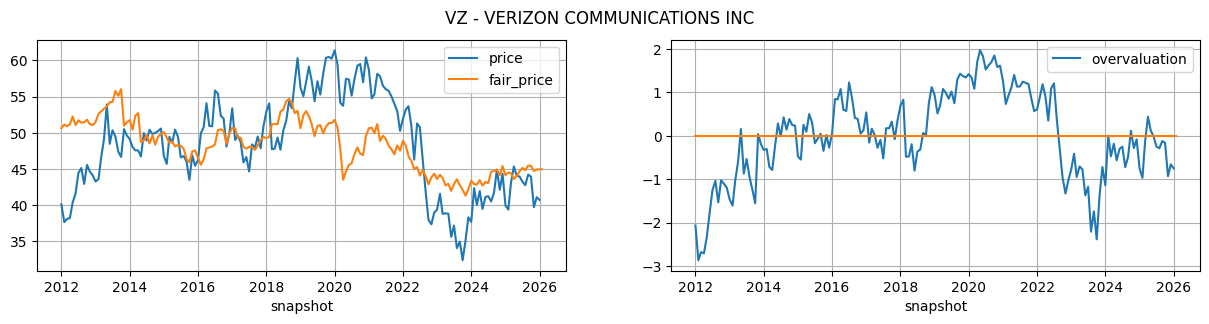

VZ fair_price = 0.128132 * (0.013685 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +72.752098


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000732712,2025-06-30,VZ,383.285,278.924,37.100,0.013685,1.628610,0.128132,72.752098,-213.257197,45.427062
2025-11-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,0.013685,1.507706,0.128132,72.752098,-218.692736,44.730596
2025-12-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,0.013685,1.548493,0.128132,72.752098,-217.124268,44.931567
2026-01-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,0.013685,1.554836,0.128132,72.752098,-216.880362,44.962819
2026-01-24,0000732712,2025-09-30,VZ,388.331,281.986,38.455,0.013685,1.554836,0.128132,72.752098,-216.880362,44.962819


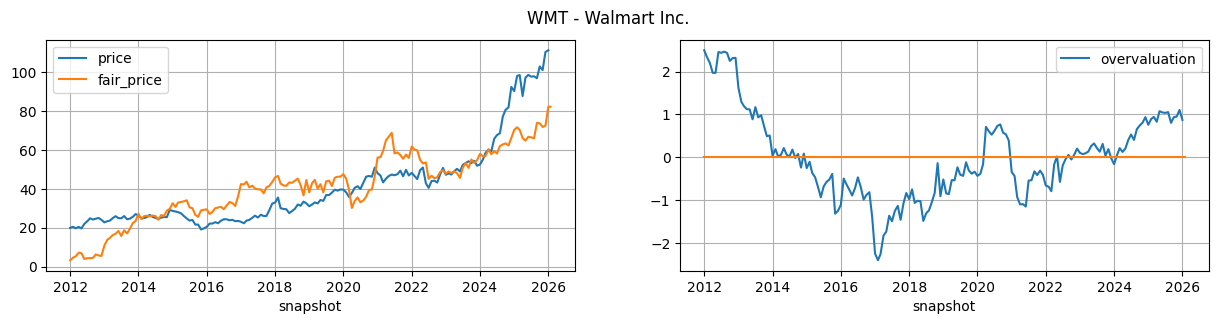

WMT fair_price = 0.407806 * (1.776058 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -74.221453


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000104169,2025-07-31,WMT,270.837,180.727,38.438,1.776058,1.628610,0.407806,-74.221453,362.895726,73.769456
2025-11-01,0000104169,2025-07-31,WMT,270.837,180.727,38.438,1.776058,1.507706,0.407806,-74.221453,358.248419,71.874258
2025-12-01,0000104169,2025-07-31,WMT,270.837,180.727,38.438,1.776058,1.548493,0.407806,-74.221453,359.816193,72.513606
2026-01-01,0000104169,2025-10-31,WMT,288.655,192.561,40.977,1.776058,1.554836,0.407806,-74.221453,383.819521,82.302297
2026-01-24,0000104169,2025-10-31,WMT,288.655,192.561,40.977,1.776058,1.554836,0.407806,-74.221453,383.819521,82.302297


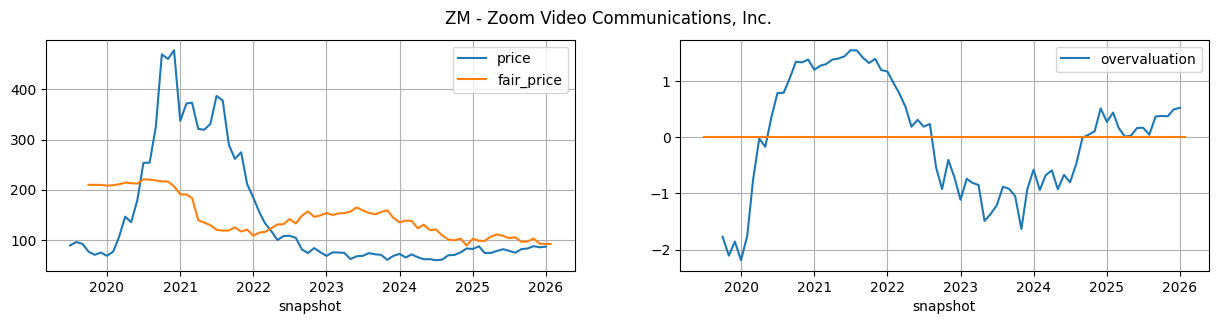

ZM fair_price = -25.553932 * (0.319298 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +212.759701


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001585521,2025-07-31,ZM,11.044063,2.093986,1.912984,0.319298,1.628610,-25.553932,212.759701,4.547869,96.543777
2025-11-01,0001585521,2025-07-31,ZM,11.044063,2.093986,1.912984,0.319298,1.507706,-25.553932,212.759701,4.316581,102.454078
2025-12-01,0001585521,2025-10-31,ZM,11.390811,2.103971,2.059093,0.319298,1.548493,-25.553932,212.759701,4.721586,92.104611
2026-01-01,0001585521,2025-10-31,ZM,11.390811,2.103971,2.059093,0.319298,1.554836,-25.553932,212.759701,4.734646,91.770874
2026-01-24,0001585521,2025-10-31,ZM,11.390811,2.103971,2.059093,0.319298,1.554836,-25.553932,212.759701,4.734646,91.770874


In [17]:
sample_tickers = ["AAPL","ADBE","ADSK","AMD","AMZN","BYND","CAT","COIN","COST","CRSR","CSCO",
                "DIS","ENPH","F","FDX","FSLR","GM","GME","GOOG","GPRO","IBM","ILMN","INTC","IRBT","JNJ","KO"
                "LYFT","META","MMM","MRNA","MSFT","MU","NFLX","NKE","NVDA","ORCL","PFE","PINS","PLTR","PTON","PYPL",
                "ROKU","RUN","T","TDOC","TGT","TLRY","TSLA","UBER","UPS","V","VZ","WMT","ZM"]

market_median_asmul = result['asmul'].groupby(by=['snapshot']).median().rename('market_median_asmul')

def plot_ticker(a_group):
    (ticker, cik), df = a_group
    try:
        name = tickers.loc[cik]['name']
    except:
        name = ""

    df = df.reset_index().set_index('snapshot')

    # The asset and cash multipliers are not available for the most recent snapshots,
    # which are not part of the stock prices dataset.
    # We use the last available cash multiplier for the fair price calculation
    df['asmul'] = df['asmul'].interpolate()
    df['cashmul'] = df['cashmul'].interpolate()
    df['fair_model'] = df['asmul'] * df['Assets'] - df['Liabilities'] + df['cashmul']*df['NetCashOperating_ttm']
    df['fair_price'] = df['fair_model'] * df['slope'] + df['intercept']
    df['overvaluation'] = -1 * preprocessing.scale(df['fair_price']/df['price'])

    # Display two plots side-by-side: of the price & fair-price and of the scaled overvaluation estimate.
    fig, (ax1, ax2) = plt.subplots(1,2)
    fig.suptitle(f"{ticker} - {name}")
    fig.set_size_inches(15,5)
    df[['price','fair_price']].plot(ax=ax1, grid=True, legend=True)
    df['overvaluation'].plot(ax=ax2, grid=True, legend=True, figsize=(15,3))
    pd.Series([0.0]*len(df.index),index=df.index).plot(ax=ax2,grid=True)
    plt.show()

    # Here we spell out our pricing model explicitly
    print("{} fair_price = {:.6f} * ({:.6f} * Assets - Liabilities + cashmul * NetCashOperating_ttm) {}{:.6f}".format(
        ticker, df['slope'].mean(), df['asmul'].mean(),
        "+" if df['intercept'].mean() >= 0 else "", df['intercept'].mean()
    ))

    # Display a few most recent records from the resultset
    df = df.reset_index().set_index(['snapshot','cik'])
    display(df.tail(5).dropna(axis='columns'))

    return df

plot_output = pd.concat(list(map(plot_ticker, 
                                 result[result['ticker'].isin(sample_tickers)].groupby(by=['ticker','cik']))))

The model has a lot of room for improvement. It is easy to notice that for some stocks it produces anomalies that should be investigated further. They are probably caused by shifting corporate accounting practices over time, or there could be logical errors in the processing pipeline, which produces the SEC fundamentals dataset.

The biggest advantage of the model, however, is that its results are completely explainable.

In [18]:
# Reality check for our fair price calculation: compute its correlation with the actual prices
print(plot_output[['price','fair_price']].corr())
# Sample data
plot_output[plot_output['ticker']=='VZ']

               price  fair_price
price       1.000000    0.917258
fair_price  0.917258    1.000000


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,,,
2012-01-01,0000732712,2011-09-30,VZ,228.032,140.517,29.761,40.12,0.013685,-1.183296,-172.612401,0.128132,72.752098,-172.612401,50.634954,-2.066449
2012-02-01,0000732712,2011-09-30,VZ,228.032,140.517,29.761,37.66,0.013685,-1.051388,-168.686681,0.128132,72.752098,-168.686681,51.137964,-2.864888
2012-03-01,0000732712,2011-12-31,VZ,230.461,144.553,29.780,38.11,0.013685,-0.979141,-170.557891,0.128132,72.752098,-170.557891,50.898202,-2.678817
2012-04-01,0000732712,2011-12-31,VZ,230.461,144.553,29.780,38.23,0.013685,-0.904925,-168.347742,0.128132,72.752098,-168.347742,51.181393,-2.705615
2012-05-01,0000732712,2012-03-31,VZ,222.921,134.500,30.702,40.38,0.013685,-0.930003,-160.002203,0.128132,72.752098,-160.002203,52.250722,-2.332221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-01,0000732712,2025-06-30,VZ,383.285,278.924,37.100,43.95,0.013685,1.628610,-213.257197,0.128132,72.752098,-213.257197,45.427062,-0.162155
2025-11-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,39.74,0.013685,1.507706,-218.692736,0.128132,72.752098,-218.692736,44.730596,-0.928719
2025-12-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,41.11,0.013685,1.548493,-217.124268,0.128132,72.752098,-217.124268,44.931567,-0.656830


All overvaluation sequences are scaled, therefore directly comparable, so we can plot them together. An interesting observaton to be made here is, that the magnitudes of overvaluation and undervaluation are not symmetrical. I.e., when stocks are undervalued, they tend to be undervalued deeper, than when they are overvalued. Maybe this is due to some unidentified bias in my model, rather than a market fact.

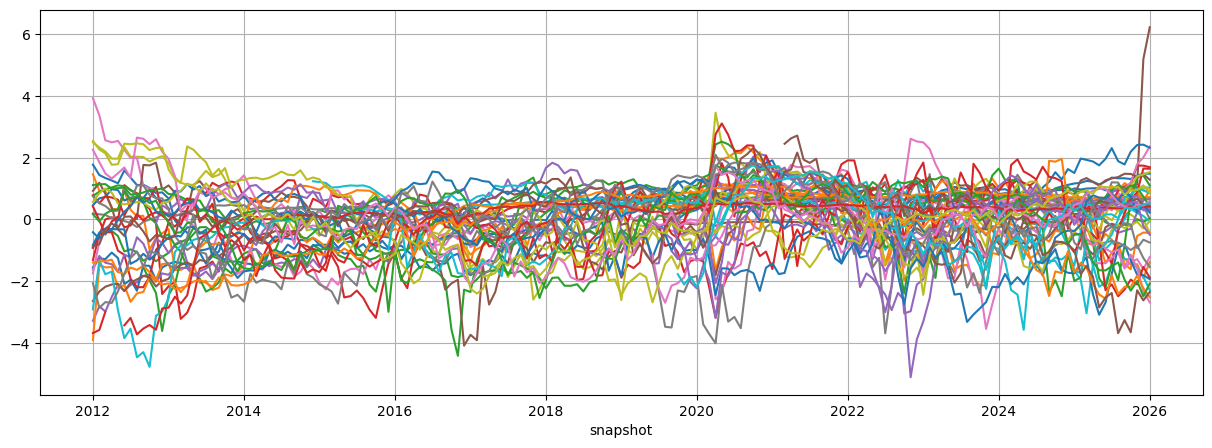

In [19]:
pd.pivot_table(plot_output, index='snapshot',columns='ticker',values='overvaluation').plot(
    grid=True, legend=False, figsize=(15,5))
plt.show()

In [20]:
print('Done without errors')

Done without errors


DISCLAIMER: The results of this model **must not** in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.